## Imports + Data Loading

In [31]:
# Modules:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from skopt import BayesSearchCV
from skopt.plots import plot_objective
from skopt.space import Real, Integer

import joblib
import pickle
import os

#Data:
X_train, y_train, X_val, y_val, X_test, y_test = None, None, None, None, None, None
with open("Data/Transformed_OutlierAdjusted/split.pkl", "rb") as file:
    data_dict = pickle.load(file)
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    X_val = data_dict["X_val"]
    y_val = data_dict["y_val"]
    X_test = data_dict["X_test"]
    y_test = data_dict["y_test"]

# As I am using CV:
X_train=pd.concat([X_train, X_val])
y_train=pd.concat([y_train, y_val])
Xcolumns = X_train.columns
ycolumns = y_train.columns

## Model Selection - With Outliers

### Function Definitions

In [30]:
def plotValidationCurve1D(gs):
    # Create validation plot around best parameter choice by keeping all but one parameter value constant
    # Select first non-constant parameter and obtain dictionary of all other parameters
    for key, value in gs.best_params_.items():
        other_items = gs.best_params_.copy()
        other_items.pop(key)
        
        #collect indices of all other parameters which are suposed to stay constant 
        indices = []
        if (len(other_items)==0): indices = [(i, item) in enumerate(gs.cv_results_["params"])]
        else:
            for i, item in enumerate(gs.cv_results_["params"]):
                match = True
                for condition_key, condition_value in other_items.items():
                    if(item[condition_key]!=condition_value):
                        match = False
                        break
                if(match==True):indices.append((i, item))  
        
        #select relevant datapoints from train/test scores
        x_axis, train_scores, train_std, test_scores, test_std = [],[],[],[],[]
        for i, item in indices:
            x_axis.append(item[key])
            train_scores.append(-gs.cv_results_["mean_train_score"][i])
            train_std.append(gs.cv_results_["std_train_score"][i])
            test_scores.append(-gs.cv_results_["mean_test_score"][i])
            test_std.append(gs.cv_results_["std_test_score"][i])

        #plot with correct labeling 
        if(len(x_axis)>1): 
            fig = plt.figure(figsize=(6,3.5))
            plt.errorbar(x=x_axis,y=train_scores, yerr= train_std, label = "Training")
            plt.errorbar(x=x_axis,y=test_scores, yerr = train_std, label = "Cross-Validation")
            plt.xlabel(key)
            plt.ylabel("MSE")
            plt.title(f"Validation Curve - Best: {gs.best_params_} - Score: {-gs.best_score_:.3f}", fontsize=10)
            plt.grid(True)
            plt.legend()
            plt.show()
    
# Conduct hyperparameter CV search with different search and fitting strategies 
def crossvalidateXGBDT(grid_parameters, cv, multi_strategy, search_strategy):
    n_cpus = os.cpu_count()-1
    kf=KFold(n_splits=cv, shuffle = True, random_state=42)

    # for multi-output => on cpu, for one output => on gpu
    if (multi_strategy=="multi_output_tree"): xgbdt = XGBRegressor(objective ="reg:squarederror", device="cpu", multi_strategy="multi_output_tree", seed=42)
    elif (multi_strategy=="one_output_per_tree"): xgbdt = XGBRegressor(objective ="reg:squarederror", device="cpu", multi_strategy="one_output_per_tree", seed=42)
    else: raise Exception("No valid multi strategy entered")
    
    if(search_strategy == "GridCV"):
        gs = GridSearchCV(
            estimator = xgbdt,
            param_grid = grid_params,
            cv = kf,
            n_jobs = n_cpus,
            scoring = "neg_mean_squared_error",
            verbose = 1,
            return_train_score = True
        )    
    elif(search_strategy == "Bayesian"):
        gs = BayesSearchCV(
            estimator = xgbdt,
            search_spaces = grid_params,
            cv = kf,
            n_jobs = n_cpus,
            n_iter = n_iter,
            scoring = "neg_mean_squared_error",
            verbose = 0,
            return_train_score = True
        )    
    else: raise Exception("No valid search strategy entered")

    # Plot Results:
    xgbdt_gs = gs.fit(X_train, y_train)
    print("Best:", xgbdt_gs.best_params_, "Score: ", -xgbdt_gs.best_score_)
    if(search_strategy == "GridCV"): plotValidationCurve1D(gs=xgbdt_gs)   
    else: _ = plot_objective(xgbdt_gs.optimizer_results_[0])
    
    return xgbdt_gs.best_estimator_

### Multi-Output-Tree

#### GridCV

##### First Optimization

Fitting 5 folds for each of 225 candidates, totalling 1125 fits
Best: {'eta': 0.4, 'max_depth': 2, 'n_estimators': 40} Score:  0.7415268742272608


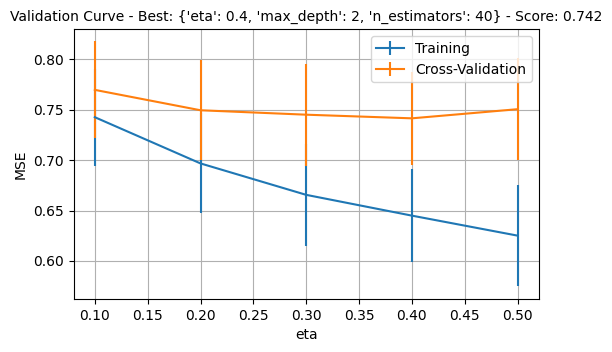

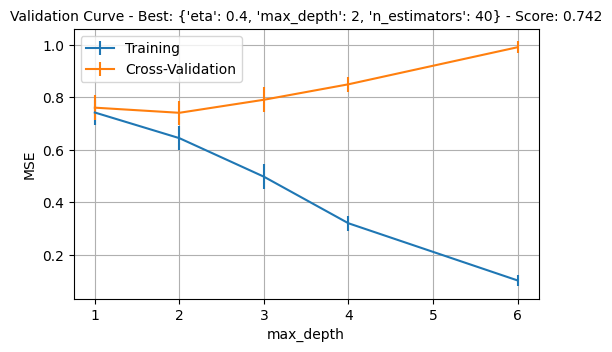

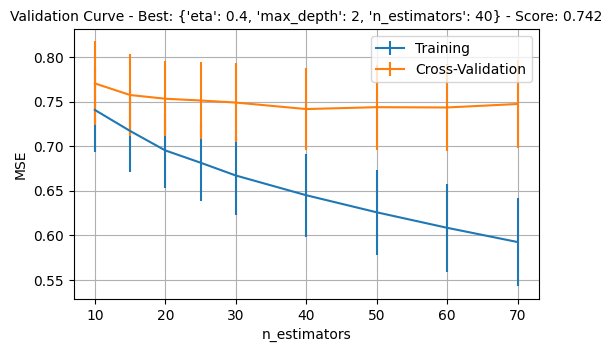

In [8]:
#Hyperparameters:
cv=5
grid_params = {
    "n_estimators": [10,15,20,25,30,40,50,60,70],
    "eta": [0.1, 0.2, 0.3, 0.4, 0.5],
    "max_depth": [1,2,3,4,6],
    # "lambda": [1],
    # "alpha": [0],
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=1m29s
# {'eta': 0.4, 'max_depth': 2, 'n_estimators': 40} Score:  0.7415268742272608


##### Second Optimization

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
Best: {'alpha': 0.01, 'eta': 0.2, 'lambda': 0.01, 'max_depth': 2, 'n_estimators': 80} Score:  0.7340844081225777


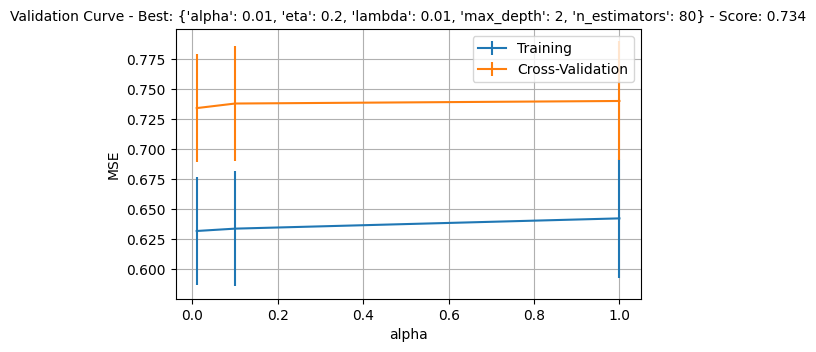

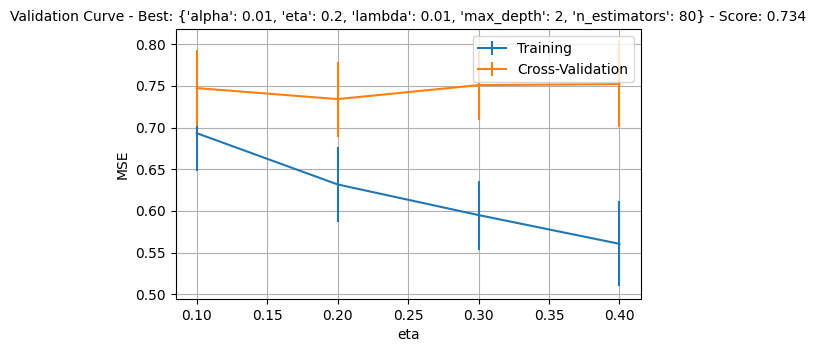

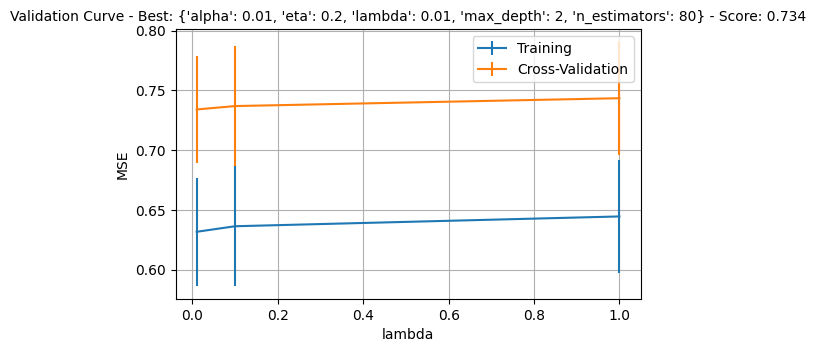

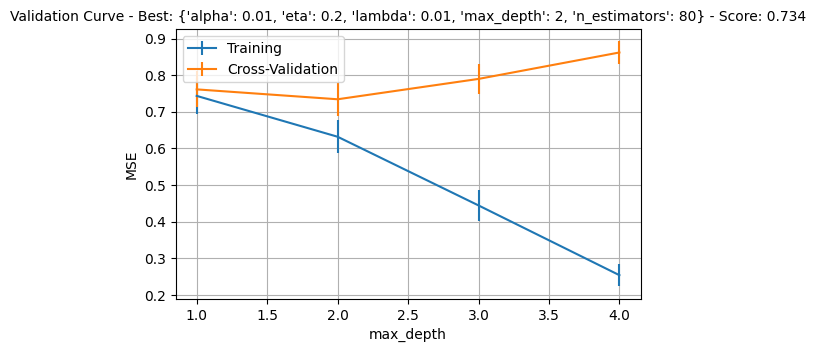

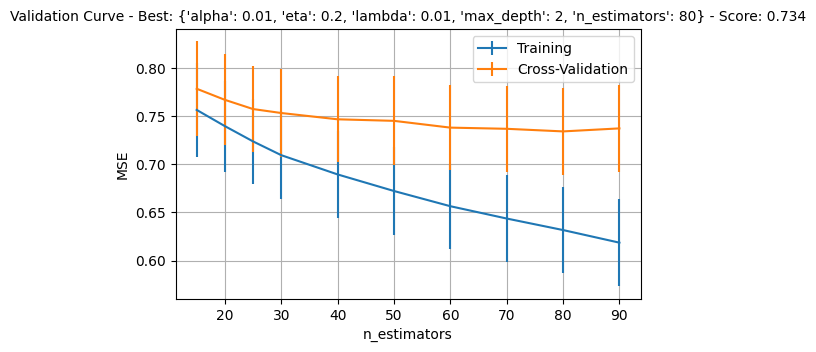

In [38]:
#Hyperparameters:
cv=5
grid_params = {
    "n_estimators": [15,20,25,30,40,50,60,70,80,90],
    "eta": [0.1, 0.2, 0.3, 0.4],
    "max_depth": [1,2,3,4],
    "lambda": [0.01, 0.1, 1],
    "alpha": [0.01, 0.1, 1]
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV2=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=4m52s
# {'alpha': 0.01, 'eta': 0.2, 'lambda': 0.01, 'max_depth': 2, 'n_estimators': 80} Score:  0.7340844081225777


##### Third Optimization

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
Best: {'alpha': 0.001, 'eta': 0.2, 'lambda': 0.01, 'max_depth': 2, 'n_estimators': 80} Score:  0.7324980158336345


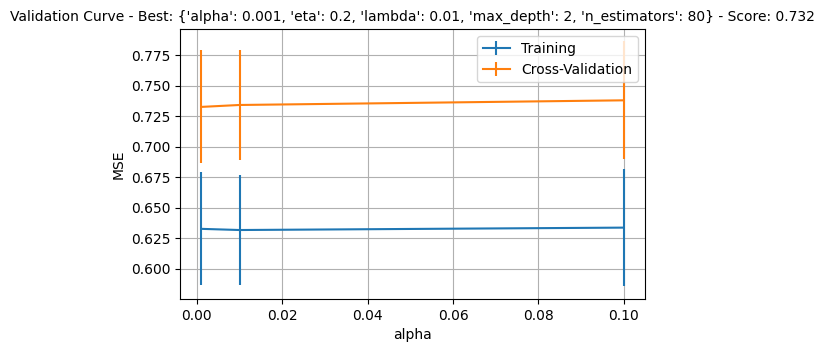

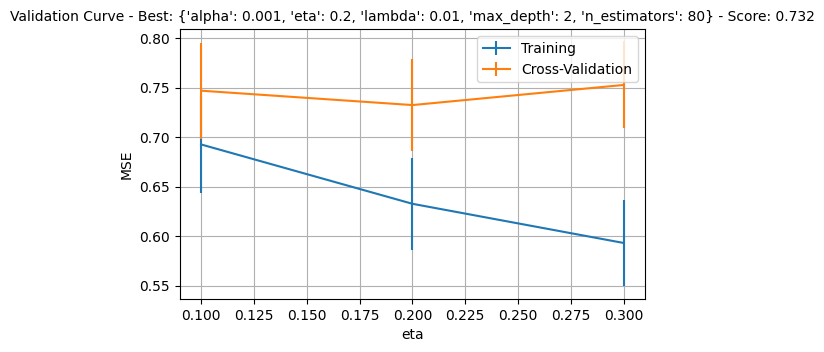

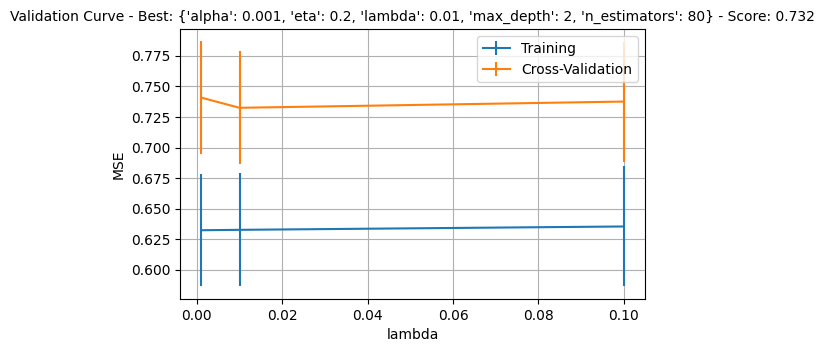

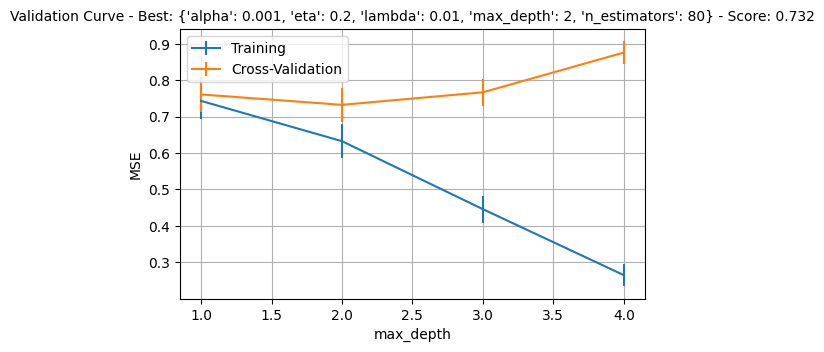

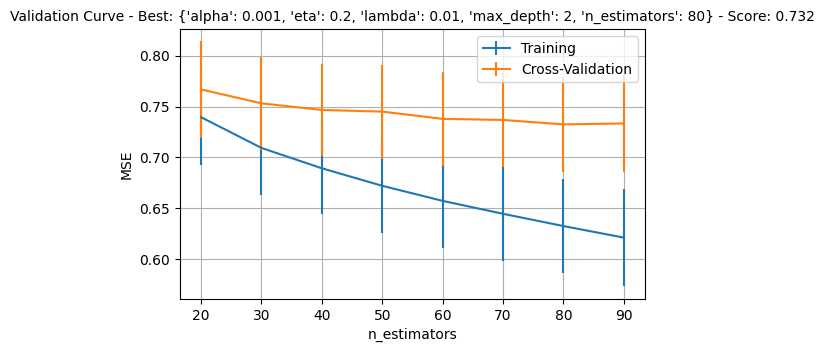

In [39]:
#Hyperparameters:
cv=5
grid_params = {
    "n_estimators": [20,30,40,50,60,70,80,90],
    "eta": [0.1, 0.2, 0.3],
    "max_depth": [1,2,3,4],
    "lambda": [0.001, 0.01, 0.05, 0.1],
    "alpha": [0.001,0.01, 0.05, 0.1]
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV3=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=4m52s
# {'alpha': 0.01, 'eta': 0.2, 'lambda': 0.01, 'max_depth': 2, 'n_estimators': 80} Score:  0.7340844081225777


#### BayesianCV - Basic Parameters

##### First Optimization

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

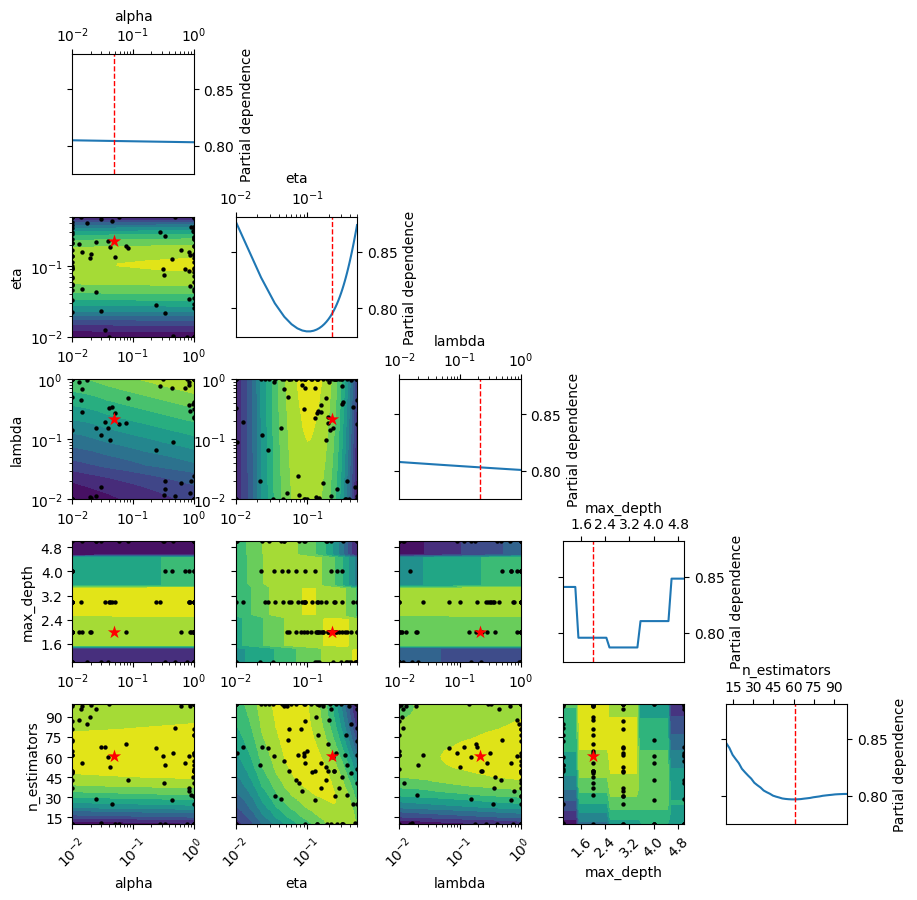

In [61]:
#Hyperparameters:
cv=5
n_iter=100
grid_params = {
    "n_estimators": Integer(10,100),
    "eta": Real(0.01, 0.5, prior="log-uniform"),
    "max_depth": Integer(1,5),
    "lambda": Real(0.01, 1, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform")
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=6m
# ('alpha', 0.04840673455912224), ('eta', 0.22335400454494236), ('lambda', 0.21346629648241397), ('max_depth', 2), ('n_estimators', 61)]) Score:  0.7374006778298254


##### Second Optimization

Best: OrderedDict([('alpha', 3.3061710475031356), ('eta', 0.13617837945721054), ('lambda', 25.066920331033224), ('max_depth', 3), ('n_estimators', 97)]) Score:  0.7364534143594514


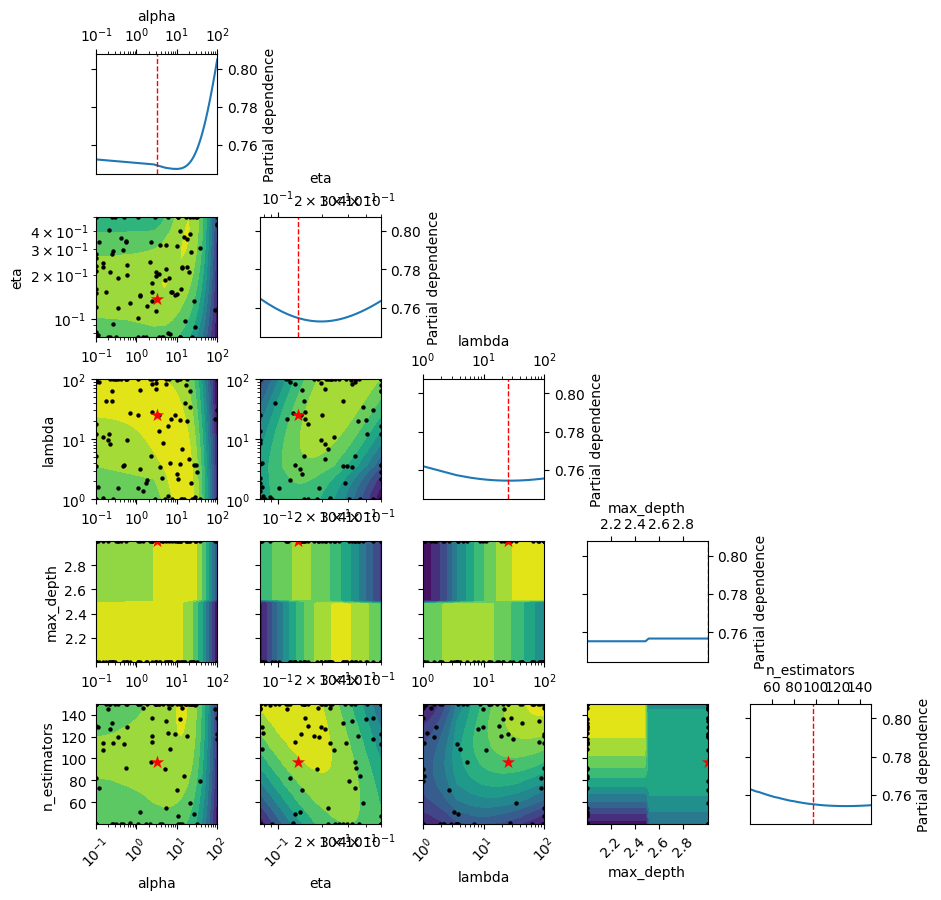

In [11]:
#Hyperparameters:
cv=5
n_iter=100
grid_params = {
    "n_estimators": Integer(40,90),
    "eta": Real(0.01, 0.5, prior="log-uniform"),
    "max_depth": Integer(2,3),
    "lambda": Real(0.1, 10, prior="log-uniform"),
    "alpha": Real(0.1, 10, prior="log-uniform")
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )
# Best Model in t=6m
# ('alpha', 3.3061710475031356), ('eta', 0.13617837945721054), ('lambda', 25.066920331033224), ('max_depth', 3), ('n_estimators', 97)]) Score:  0.7364534143594514


##### Third Optimization

Best: OrderedDict([('alpha', 8.209836427531021), ('eta', 0.1515633271052176), ('lambda', 20.845697783746097), ('max_depth', 3), ('n_estimators', 119)]) Score:  0.7354182385911724


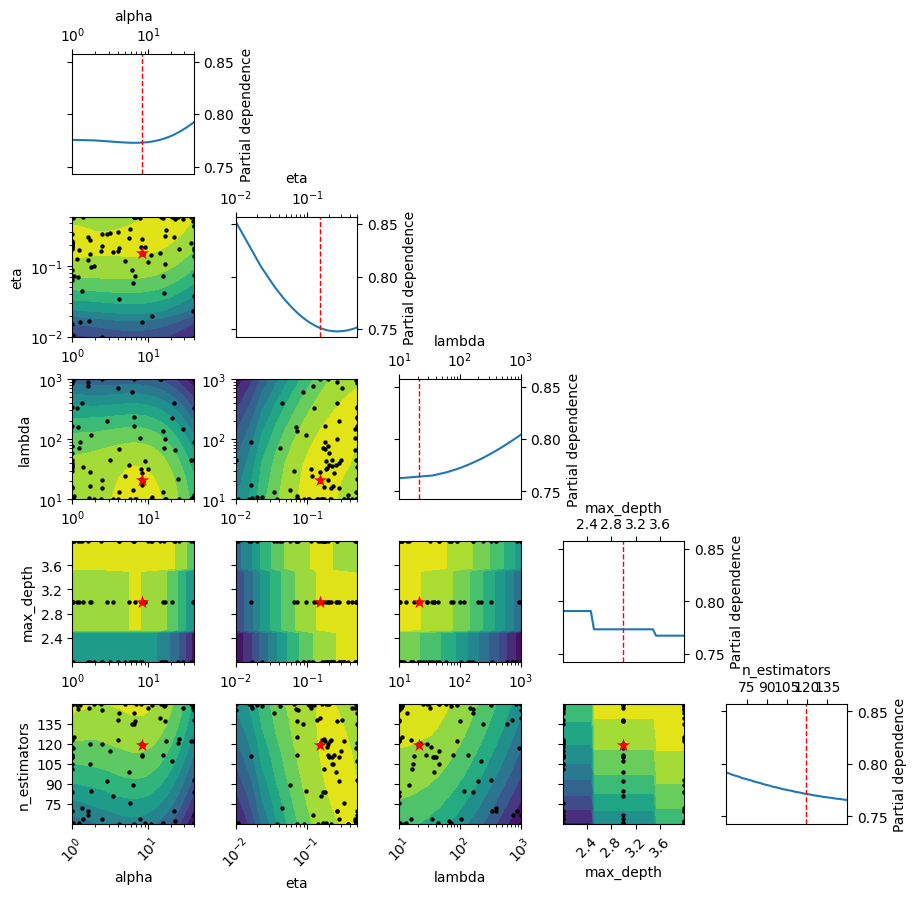

In [12]:
#Hyperparameters:
cv=5
n_iter=100
grid_params = {
    "n_estimators": Integer(60,150),
    "eta": Real(0.01, 0.5, prior="log-uniform"),
    "max_depth": Integer(2,4),
    "lambda": Real(10, 1000, prior="log-uniform"),
    "alpha": Real(1, 40, prior="log-uniform")
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )
# Best Model in t=m
# ('alpha', 8.209836427531021), ('eta', 0.1515633271052176), ('lambda', 20.845697783746097), ('max_depth', 3), ('n_estimators', 119)]) Score:  0.7354182385911724

#### Advanced Parameters

##### First Optimization

Best: OrderedDict([('alpha', 0.01), ('colsample_bytree', 1.0), ('eta', 0.29968074365668046), ('gamma', 0.0), ('lambda', 0.01), ('max_depth', 1), ('n_estimators', 100), ('subsample', 1.0)]) Score:  0.7488303049358587


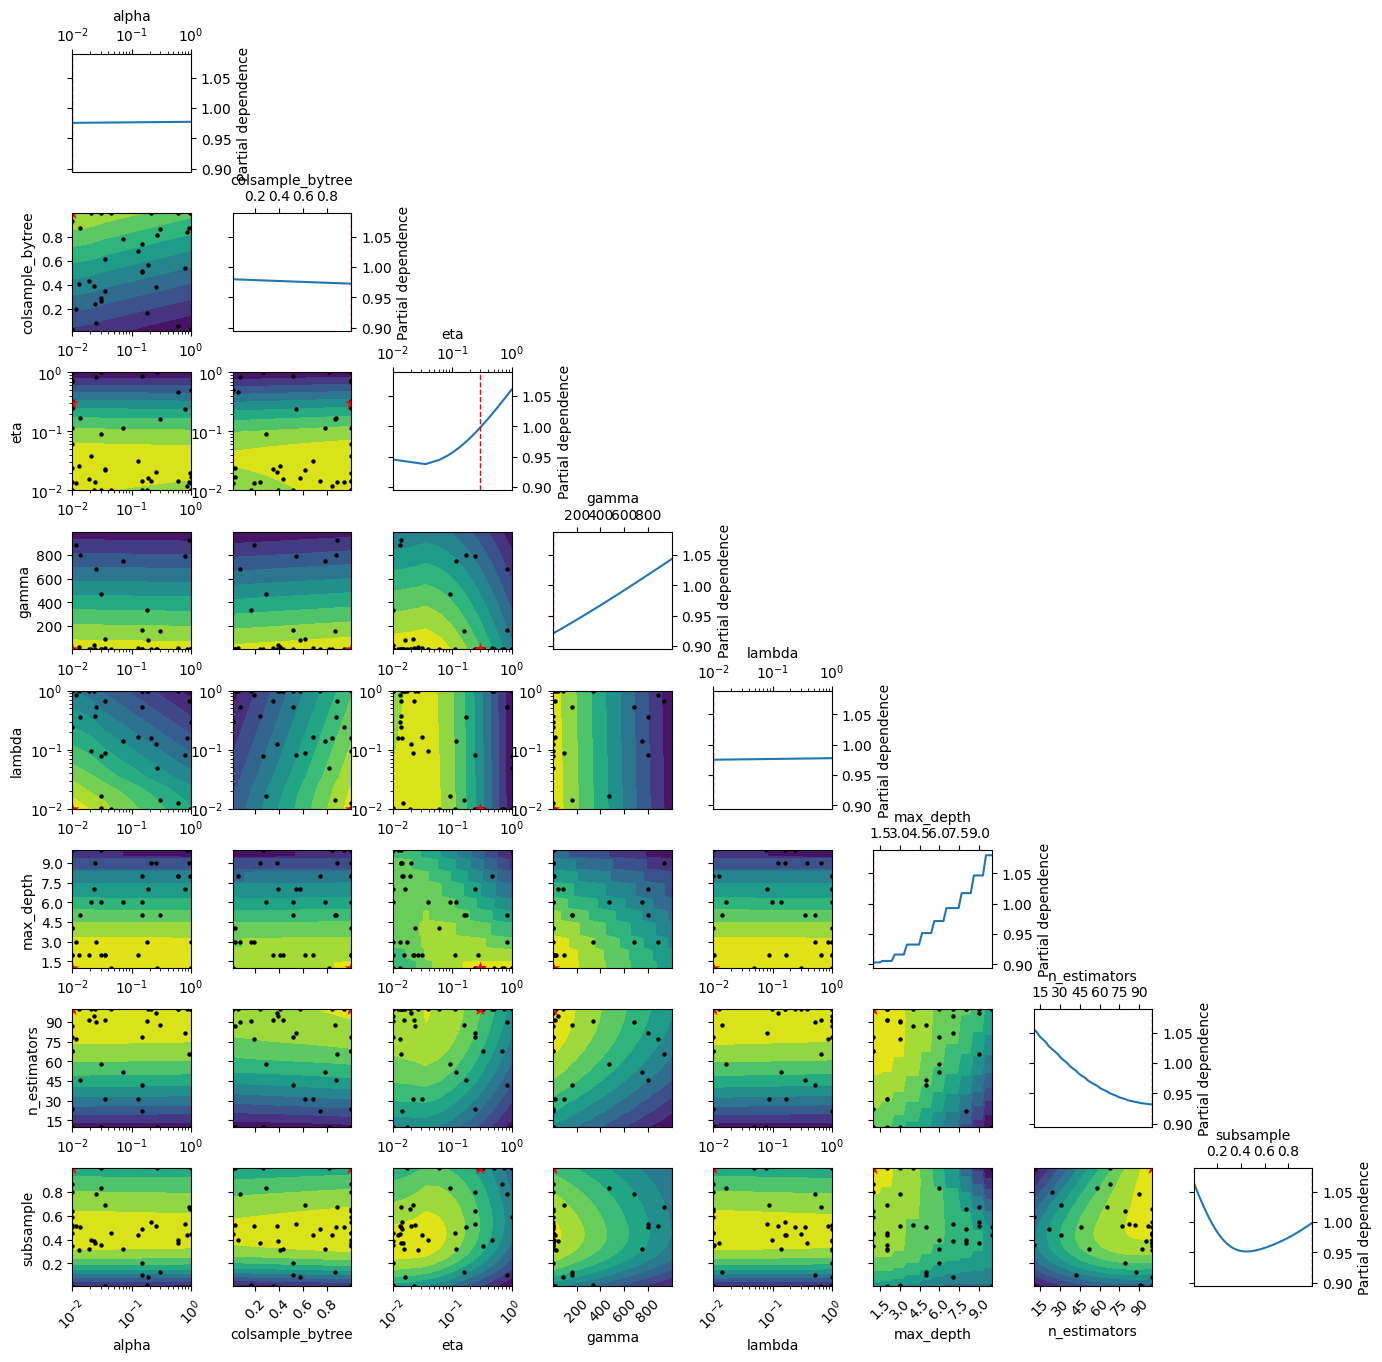

In [18]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(10,100),
    "eta": Real(0.01, 1, prior="log-uniform"),
    "max_depth": Integer(1,10),
    "lambda": Real(0.01, 1, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform"),
    "gamma": Real(0,1000),
    "subsample": Real(0.01,1),
    "colsample_bytree": Real(0.01,1)
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=3.5m
# ('alpha', 0.01), ('colsample_bytree', 1.0), ('eta', 0.29968074365668046), ('gamma', 0.0), ('lambda', 0.01), ('max_depth', 1), ('n_estimators', 100), ('subsample', 1.0)]) Score:  0.7488303049358587


##### Second Optimization

Best: OrderedDict([('alpha', 0.010991922267469268), ('colsample_bytree', 0.6691565011678673), ('eta', 0.01614458163110505), ('gamma', 0.0), ('lambda', 1.0), ('max_depth', 4), ('n_estimators', 200), ('subsample', 1.0)]) Score:  0.7502368038247006


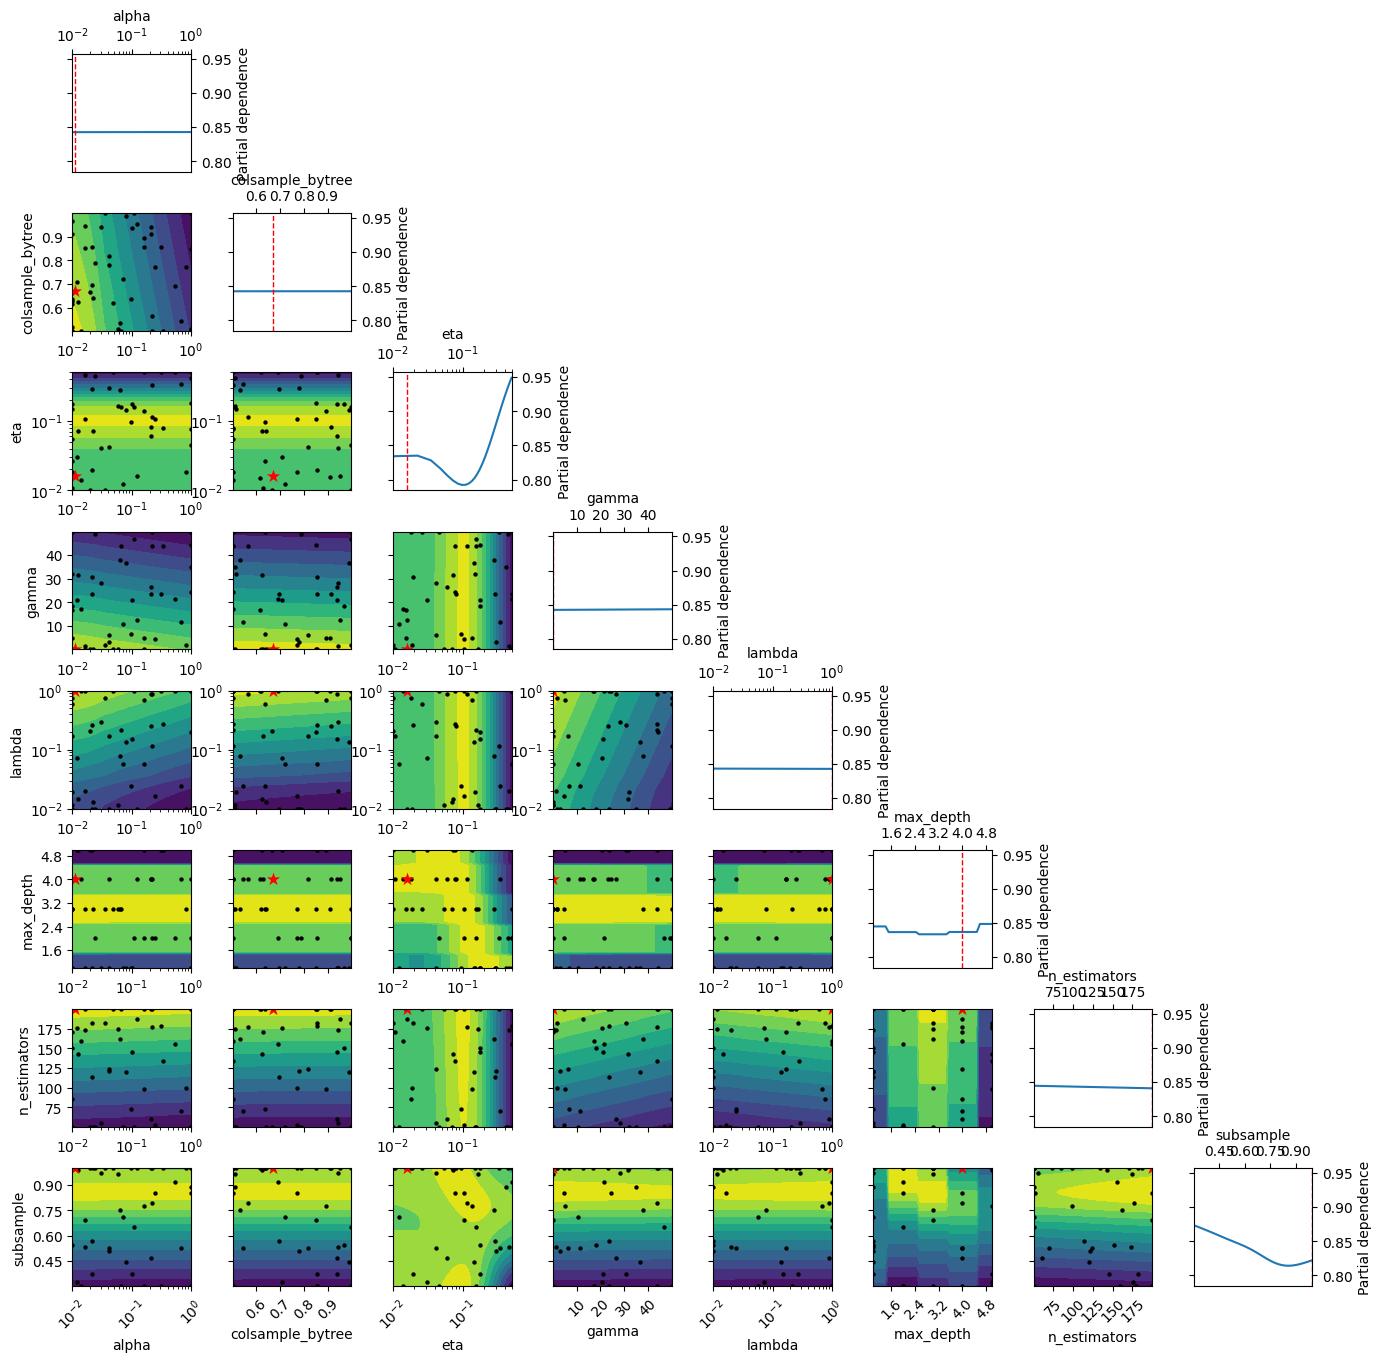

In [19]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(50,200),
    "eta": Real(0.01, 0.5, prior="log-uniform"),
    "max_depth": Integer(1,5),
    "lambda": Real(0.01, 1, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform"),
    "gamma": Real(0,50),
    "subsample": Real(0.3,1),
    "colsample_bytree": Real(0.5,1)
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=3m
# ('alpha', 0.010991922267469268), ('colsample_bytree', 0.6691565011678673), ('eta', 0.01614458163110505), ('gamma', 0.0), ('lambda', 1.0), ('max_depth', 4), ('n_estimators', 200), ('subsample', 1.0)]) Score:  0.7502368038247006

##### Third Optimization

Best: OrderedDict([('alpha', 0.017705718990916965), ('colsample_bytree', 1.0), ('eta', 0.1323692709522213), ('gamma', 2.3833093352521297), ('lambda', 10.0), ('max_depth', 3), ('n_estimators', 77), ('subsample', 0.9865401617258858)]) Score:  0.7425026820800302


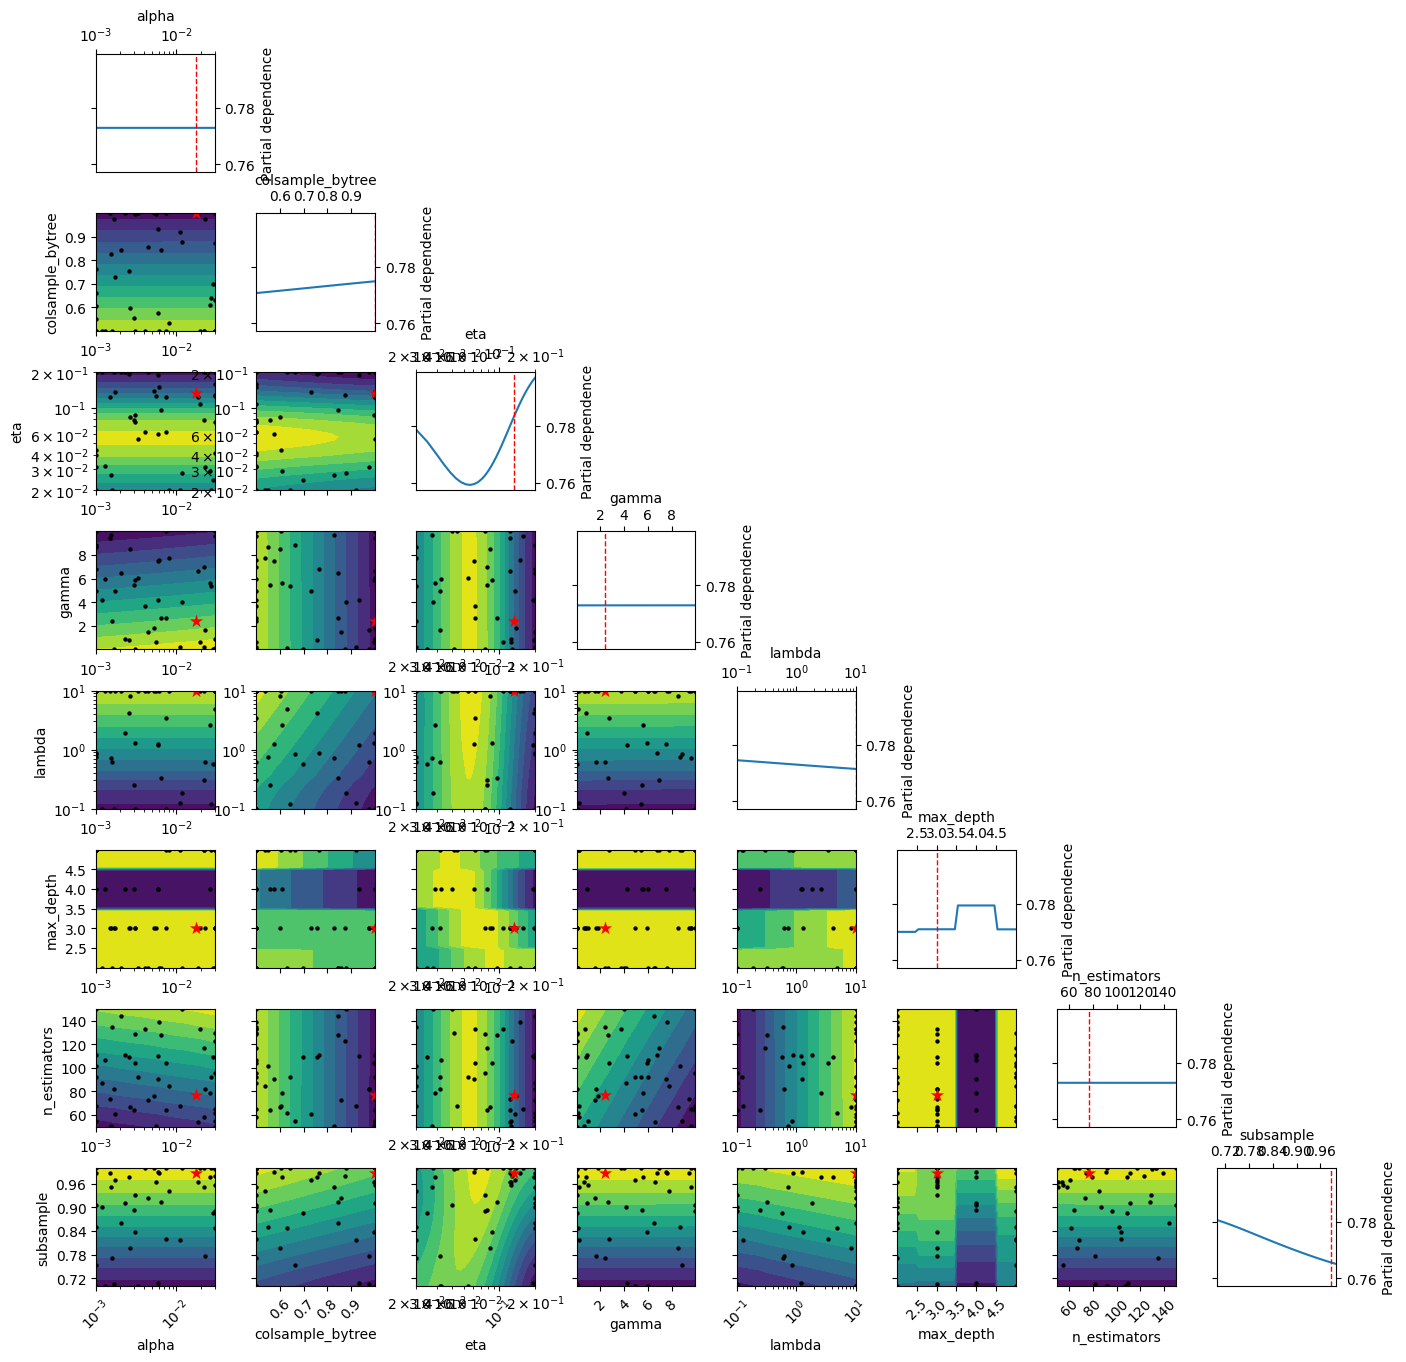

In [20]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(50,150),
    "eta": Real(0.02, 0.2, prior="log-uniform"),
    "max_depth": Integer(2,5),
    "lambda": Real(0.1, 10, prior="log-uniform"),
    "alpha": Real(0.001, 0.03, prior="log-uniform"),
    "gamma": Real(0,10),
    "subsample": Real(0.7,1),
    "colsample_bytree": Real(0.5,1)
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=3m
# ('alpha', 0.017705718990916965), ('colsample_bytree', 1.0), ('eta', 0.1323692709522213), ('gamma', 2.3833093352521297), ('lambda', 10.0), ('max_depth', 3), ('n_estimators', 77), ('subsample', 0.9865401617258858)]) Score:  0.7425026820800302

##### Fourth Optimization

Best: OrderedDict([('colsample_bytree', 1.0), ('eta', 0.2), ('lambda', 100.0), ('max_depth', 2), ('n_estimators', 200), ('subsample', 1.0)]) Score:  0.7424355699164616


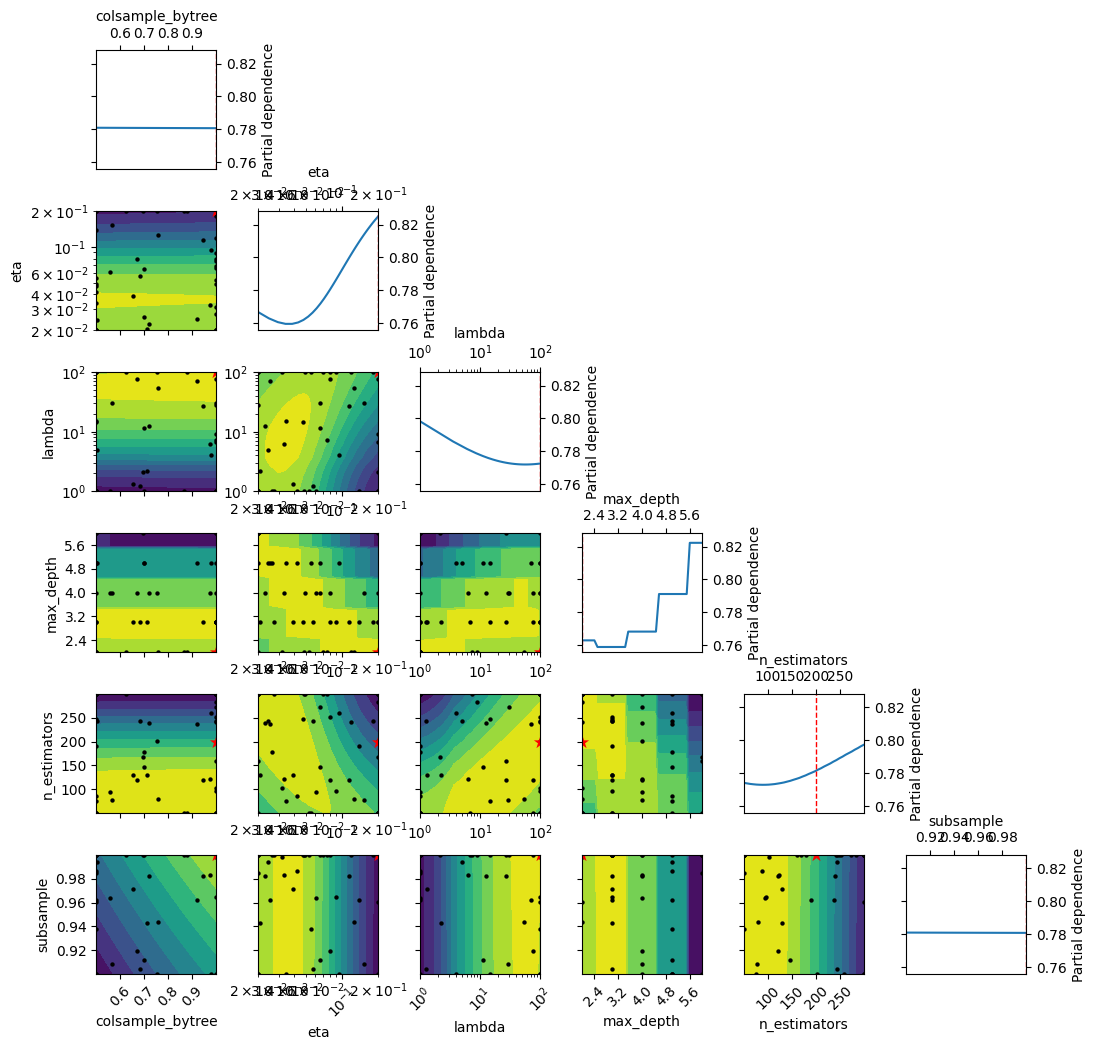

In [21]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(50,300),
    "eta": Real(0.02, 0.2, prior="log-uniform"),
    "max_depth": Integer(2,6),
    "lambda": Real(1, 100, prior="log-uniform"),
    # "alpha": Real(0.01, 0.1, prior="log-uniform"),
    # "gamma": Real(0,10),
    "subsample": Real(0.9,1),
    "colsample_bytree": Real(0.5,1)
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=3m
# [('colsample_bytree', 1.0), ('eta', 0.2), ('lambda', 100.0), ('max_depth', 2), ('n_estimators', 200), ('subsample', 1.0)]) Score:  0.7424355699164616

##### Fifth Optimization

Best: OrderedDict([('colsample_bytree', 0.5), ('eta', 0.05650336840439749), ('lambda', 26.291292860691247), ('max_depth', 4), ('n_estimators', 200), ('subsample', 1.0)]) Score:  0.738048897245382


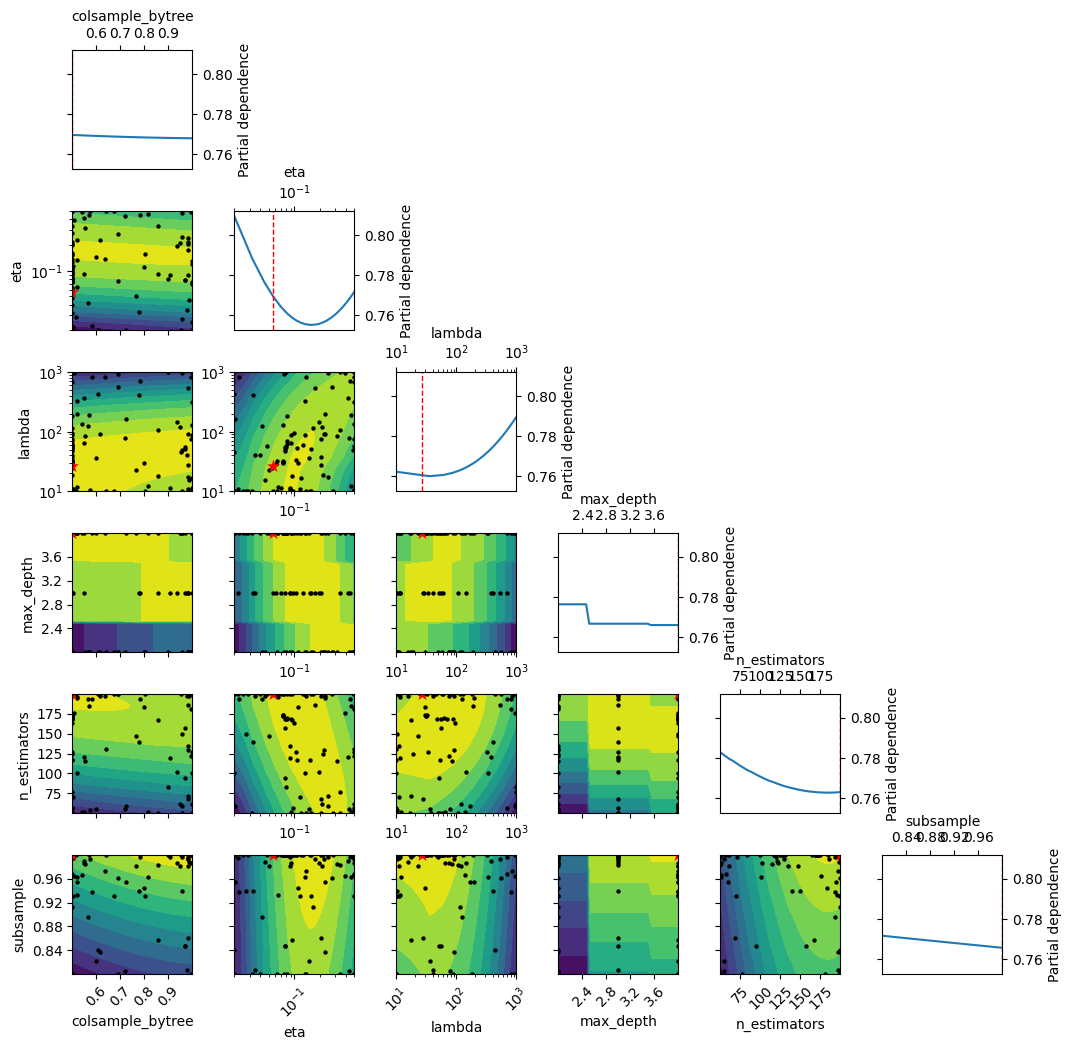

In [22]:
#Hyperparameters:
cv=4
n_iter=100
grid_params = {
    "n_estimators": Integer(50,200),
    "eta": Real(0.02, 0.5, prior="log-uniform"),
    "max_depth": Integer(2,4),
    "lambda": Real(10, 1000, prior="log-uniform"),
    # "alpha": Real(0.01, 0.1, prior="log-uniform"),
    # "gamma": Real(0,10),
    "subsample": Real(0.8,1),
    "colsample_bytree": Real(0.5,1)
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=7m
# [('colsample_bytree', 0.5), ('eta', 0.05650336840439749), ('lambda', 26.291292860691247), ('max_depth', 4), ('n_estimators', 200), ('subsample', 1.0)]) Score:  0.738048897245382

##### Sixth Optimization

Fitting 4 folds for each of 3360 candidates, totalling 13440 fits
Best: {'colsample_bytree': 0.95, 'eta': 0.2, 'lambda': 40, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1} Score:  0.7361029377549984


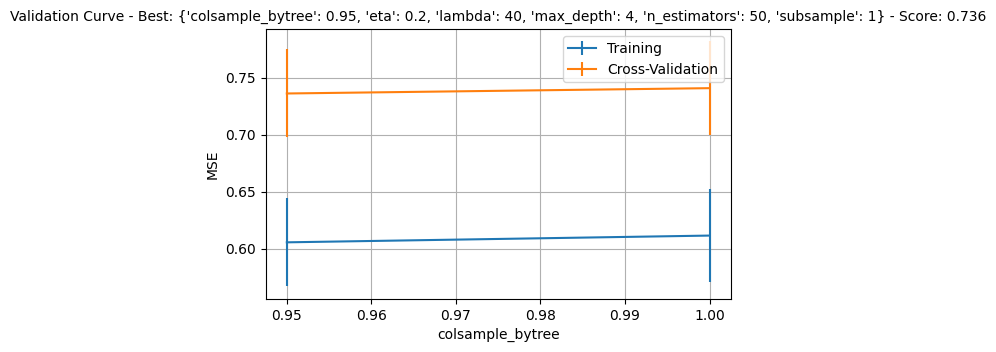

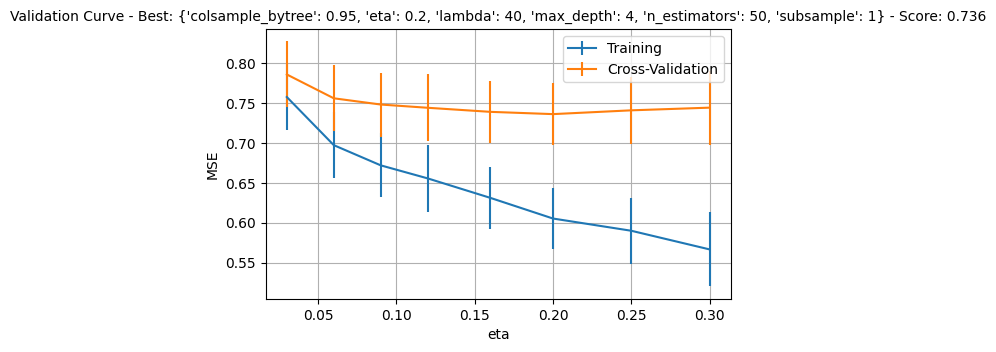

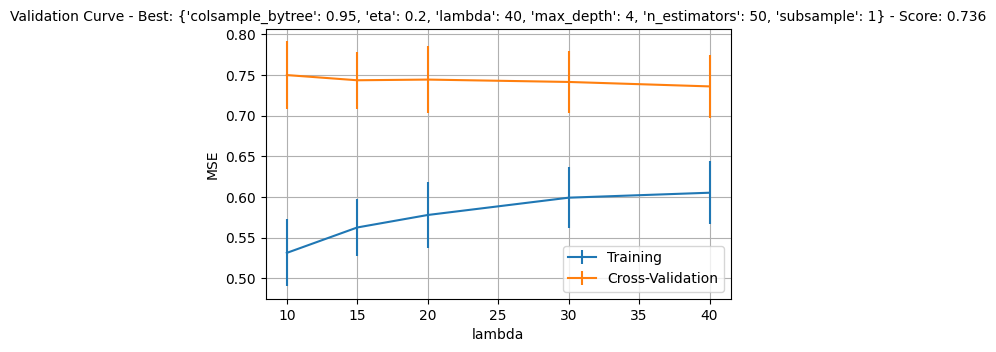

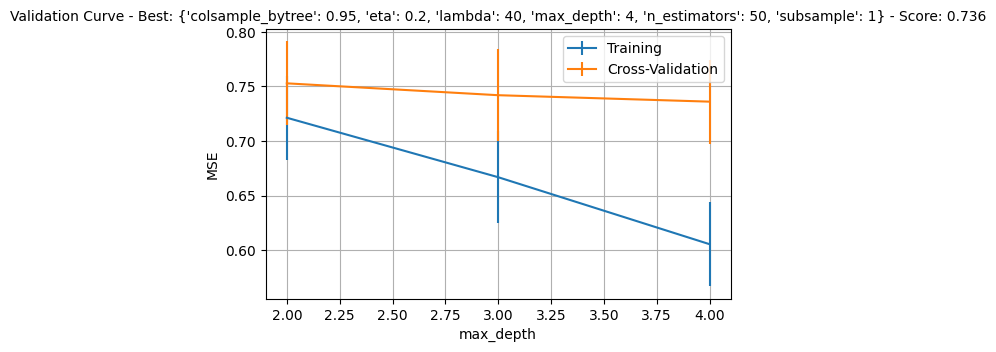

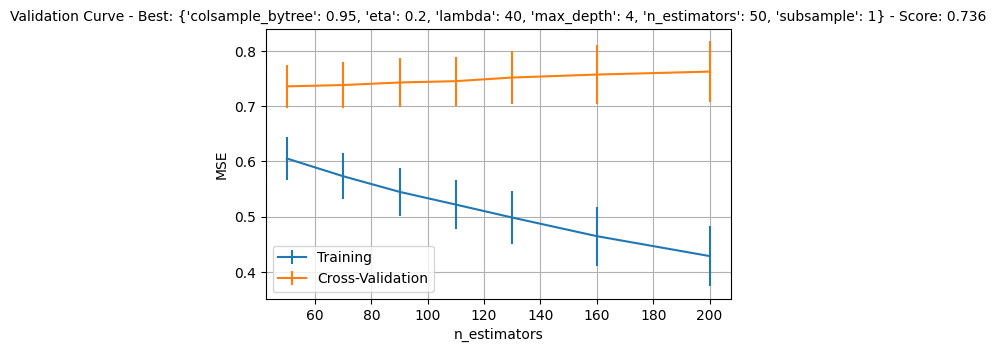

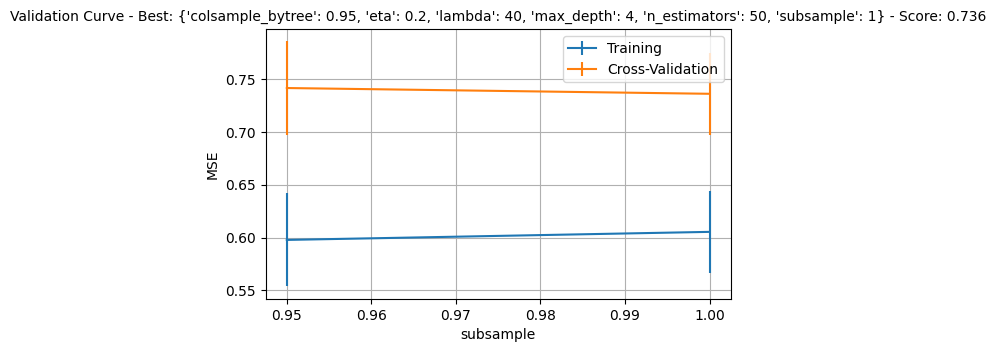

In [25]:
#Hyperparameters:
cv=4
grid_params = {
    "n_estimators": [50,70,90,110,130,160,200],
    "eta": [0.03,0.06,0.09,0.12,0.16,0.20,0.25,0.3],
    "max_depth": [2,3,4],
    "lambda": [10, 15, 20, 30, 40],
    "subsample": [0.95, 1],
    "colsample_bytree": [0.95, 1]
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV3=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=24m10s
# {'colsample_bytree': 0.95, 'eta': 0.2, 'lambda': 40, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1} Score:  0.7361029377549984

##### Seventh Optimization

Fitting 4 folds for each of 1890 candidates, totalling 7560 fits
Best: {'colsample_bytree': 0.95, 'eta': 0.2, 'lambda': 40, 'max_depth': 4, 'n_estimators': 50} Score:  0.7361029377549984


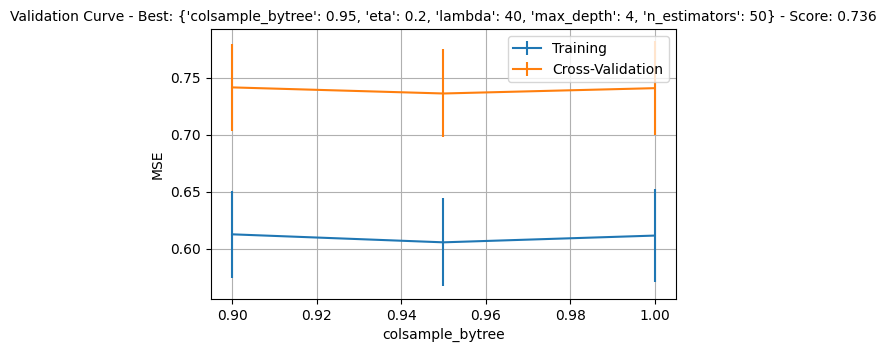

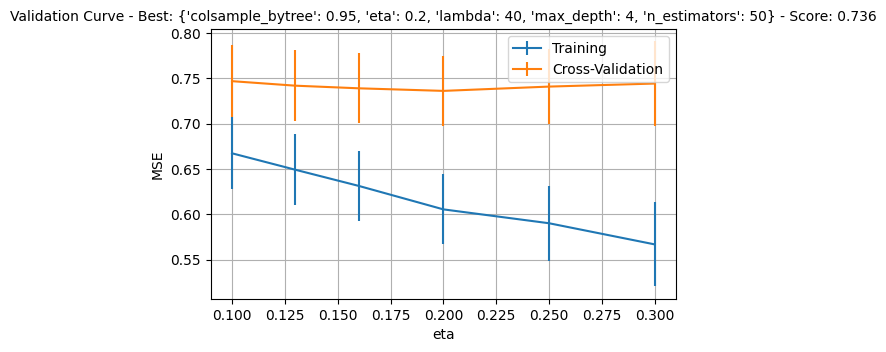

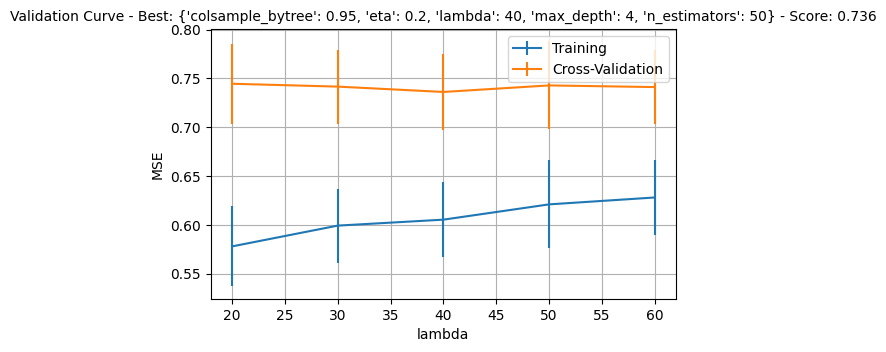

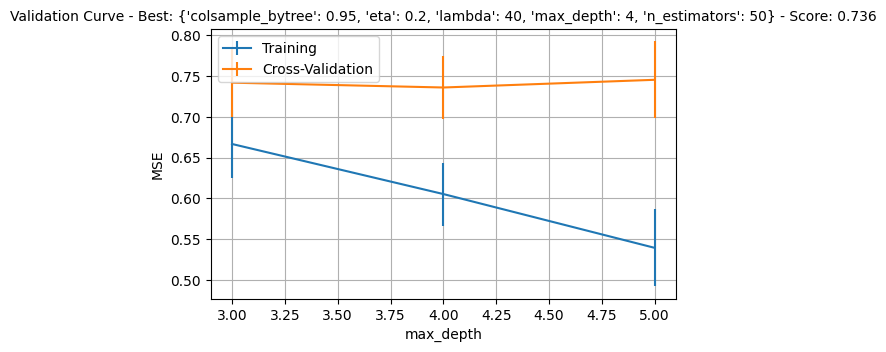

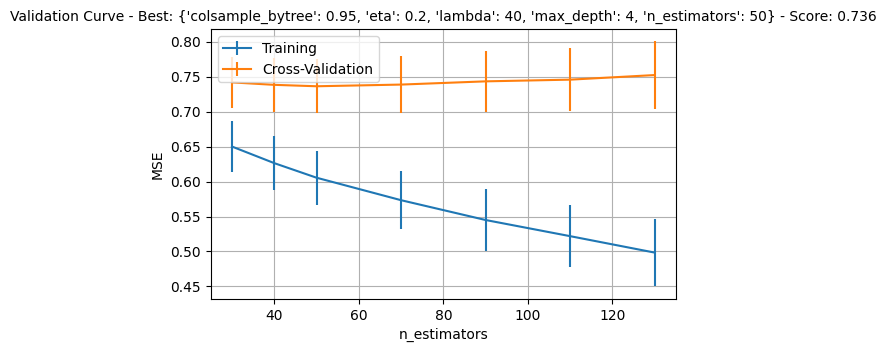

In [26]:
#Hyperparameters:
cv=4
grid_params = {
    "n_estimators": [30,40,50,70,90,110,130],
    "eta": [0.10,0.13,0.16,0.20,0.25,0.3],
    "max_depth": [3,4,5],
    "lambda": [20, 30, 40, 50, 60],
    "colsample_bytree": [0.9, 0.95, 1]
}

#Evaluate Performance
best_model_CV3=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=24m10s

### Single Output Per Tree

#### Bayesian

##### First Optimization

Best: OrderedDict([('alpha', 0.04730269265450977), ('colsample_bytree', 1.0), ('eta', 0.47654971519030587), ('gamma', 0.0), ('lambda', 0.13399111393310437), ('max_depth', 1), ('n_estimators', 100), ('subsample', 1.0)]) Score:  0.7390943923354998


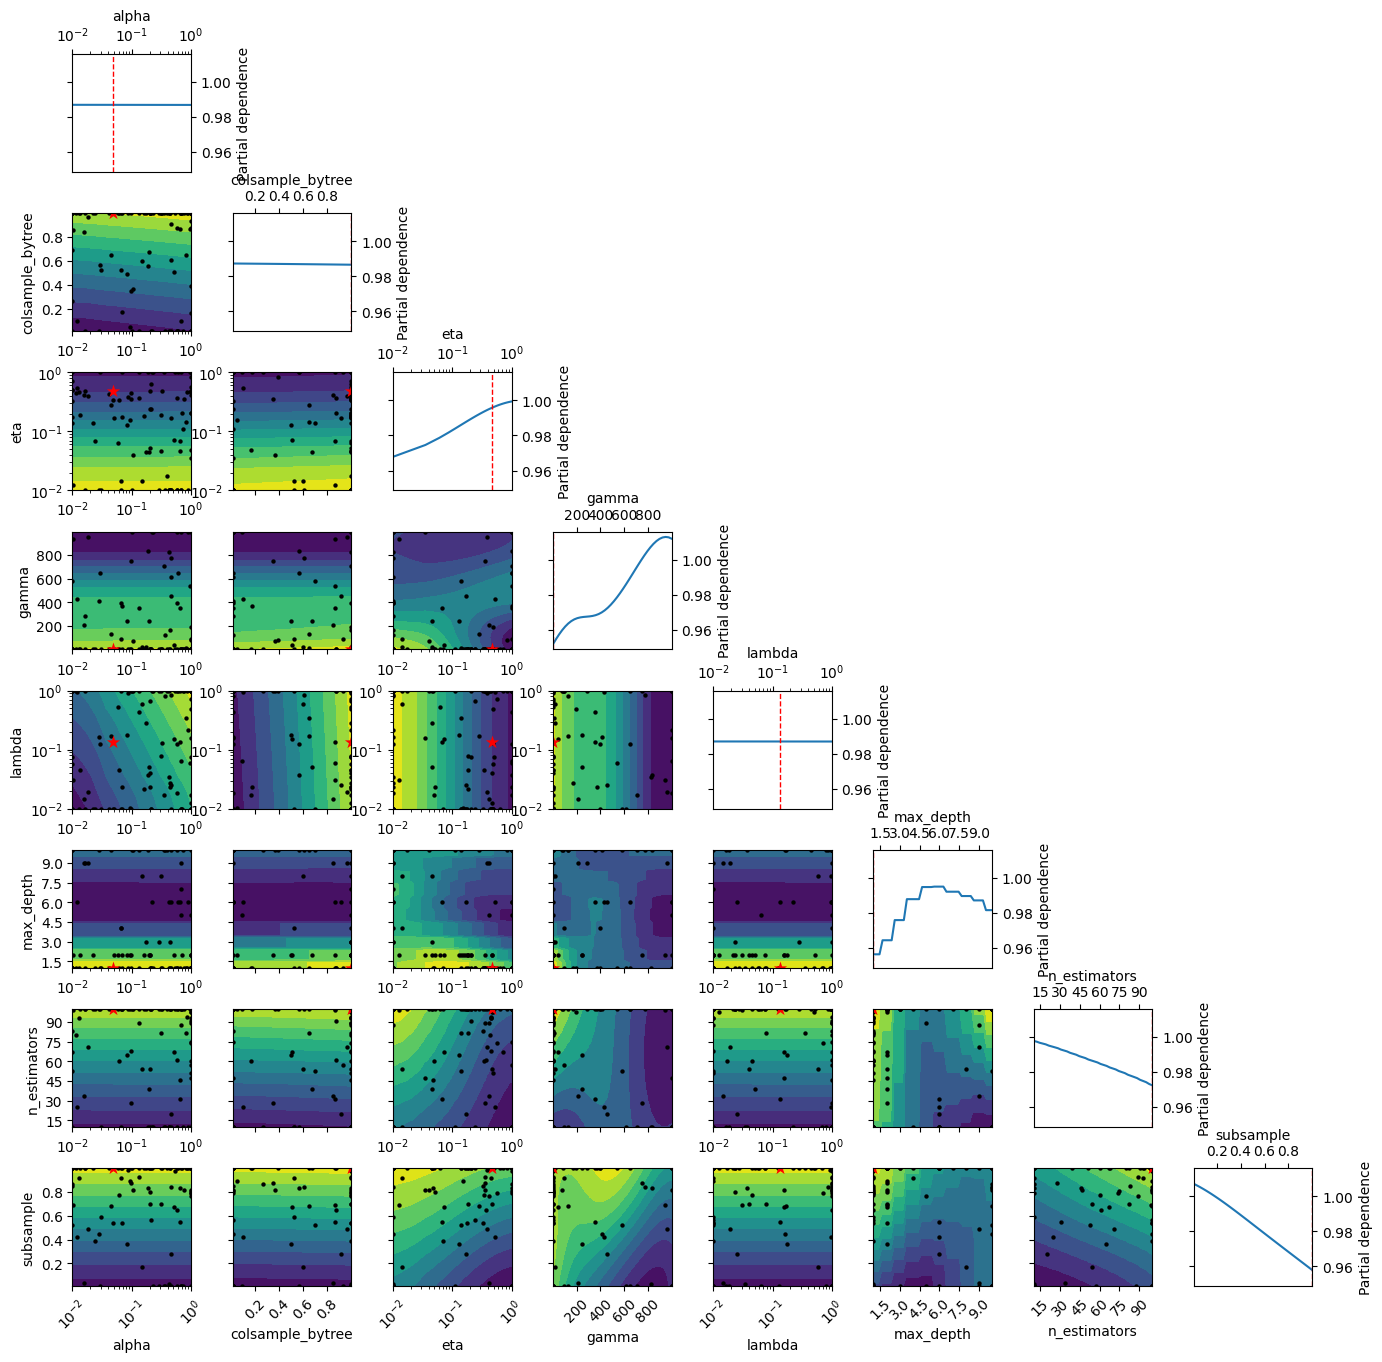

In [29]:
#Hyperparameters:
cv=3
n_iter=100
grid_params = {
    "n_estimators": Integer(10,100),
    "eta": Real(0.01, 1, prior="log-uniform"),
    "max_depth": Integer(1,10),
    "lambda": Real(0.01, 1, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform"),
    "gamma": Real(0,1000),
    "subsample": Real(0.01,1),
    "colsample_bytree": Real(0.01,1)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=9m
# [('alpha', 0.04730269265450977), ('colsample_bytree', 1.0), ('eta', 0.47654971519030587), ('gamma', 0.0), ('lambda', 0.13399111393310437), ('max_depth', 1), ('n_estimators', 100), ('subsample', 1.0)]) Score:  0.7390943923354998

##### Second Optimization

Best: OrderedDict([('alpha', 1.0), ('colsample_bytree', 0.5), ('eta', 0.1309692939446741), ('gamma', 4.31320461821143), ('lambda', 1.0), ('max_depth', 3), ('n_estimators', 82)]) Score:  0.7434626820064141


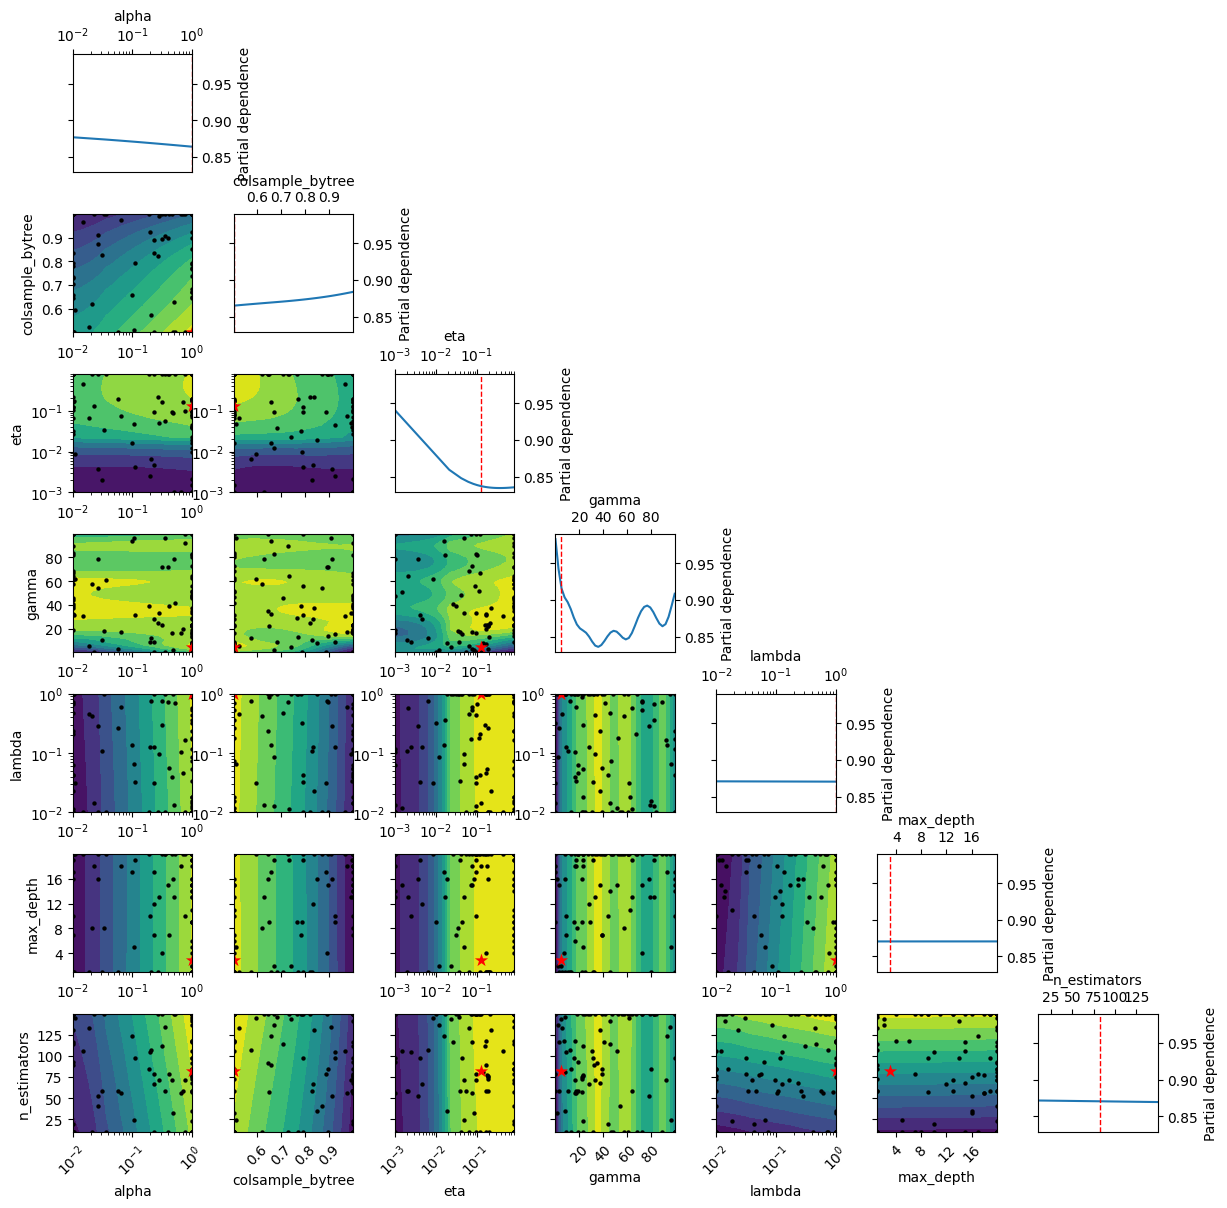

In [31]:
#Hyperparameters:
cv=3
n_iter=100
grid_params = {
    "n_estimators": Integer(10,150),
    "eta": Real(0.001, 0.8, prior="log-uniform"),
    "max_depth": Integer(1,20),
    "lambda": Real(0.01, 1, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform"),
    "gamma": Real(0,100),
    "colsample_bytree": Real(0.5,1)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=9m
# Best: ('alpha', 1.0), ('colsample_bytree', 0.5), ('eta', 0.1309692939446741), ('gamma', 4.31320461821143), ('lambda', 1.0), ('max_depth', 3), ('n_estimators', 82)]) Score:  0.7434626820064141

##### Third Optimization

Best: OrderedDict([('colsample_bytree', 0.8), ('eta', 0.20115120827770483), ('lambda', 10.0), ('max_depth', 2), ('n_estimators', 102)]) Score:  0.7398753697247669


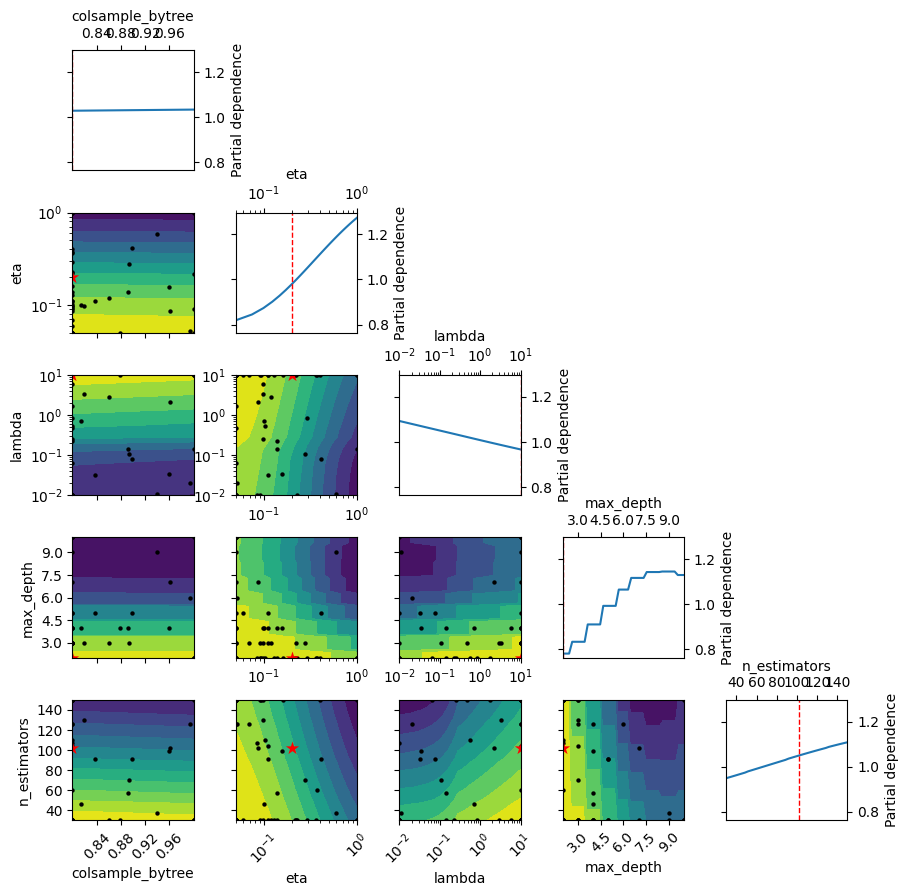

In [36]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(30,150),
    "eta": Real(0.05, 1, prior="log-uniform"),
    "max_depth": Integer(2,10),
    "lambda": Real(0.01, 10, prior="log-uniform"),
    # "alpha": Real(0.1, 10, prior="log-uniform"),
    # "gamma": Real(30,60),
    "colsample_bytree": Real(0.8,1)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=2m
# [('alpha', 0.2284145322247288), ('colsample_bytree', 0.8999999999999999), ('eta', 0.5325529087616898), ('gamma', 30.0), ('lambda', 0.01), ('max_depth', 12), ('n_estimators', 150)]) Score:  0.777282634902162

##### Fourth Optimization

Best: OrderedDict([('colsample_bytree', 1.0), ('eta', 0.29711762585476625), ('lambda', 56.0320995112443), ('max_depth', 2), ('n_estimators', 95)]) Score:  0.7377957562085796


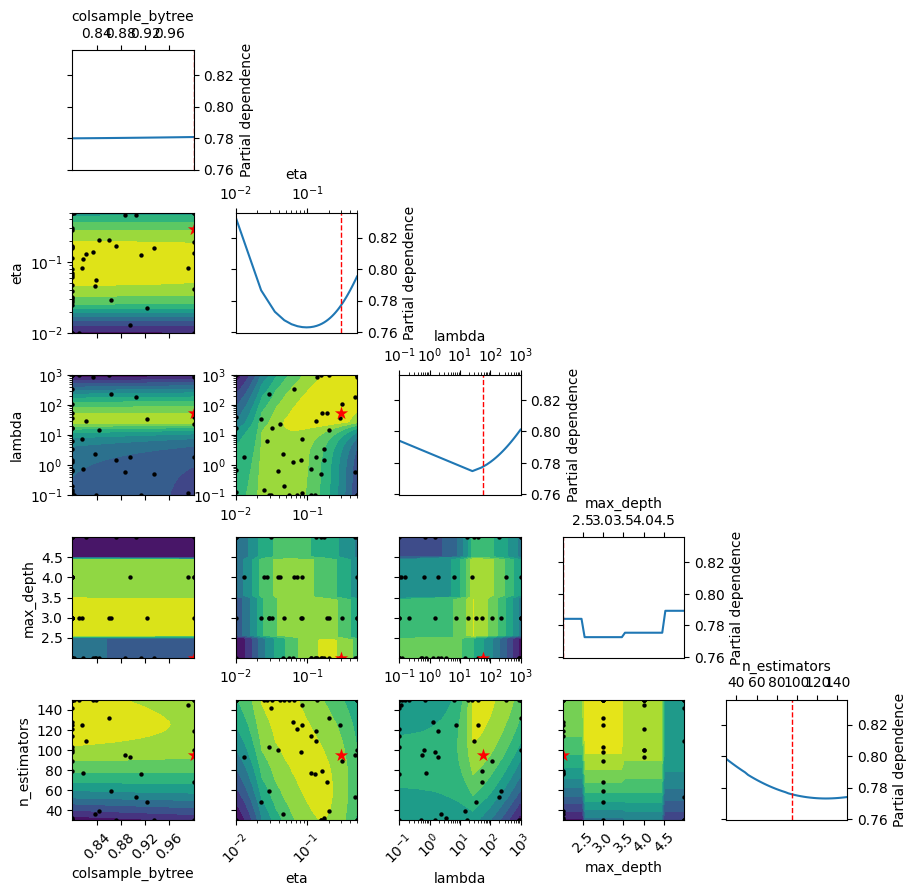

In [37]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(30,150),
    "eta": Real(0.01, 0.5, prior="log-uniform"),
    "max_depth": Integer(2,5),
    "lambda": Real(0.1, 1000, prior="log-uniform"),
    # "alpha": Real(0.1, 10, prior="log-uniform"),
    # "gamma": Real(30,60),
    "colsample_bytree": Real(0.8,1)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=2m
# ('colsample_bytree', 1.0), ('eta', 0.29711762585476625), ('lambda', 56.0320995112443), ('max_depth', 2), ('n_estimators', 95)]) Score:  0.7377957562085796

##### Fifth Optimization

Best: OrderedDict([('colsample_bytree', 0.8), ('eta', 0.24287104327930784), ('lambda', 12.948120669877431), ('max_depth', 2), ('n_estimators', 60)]) Score:  0.7376910970607561


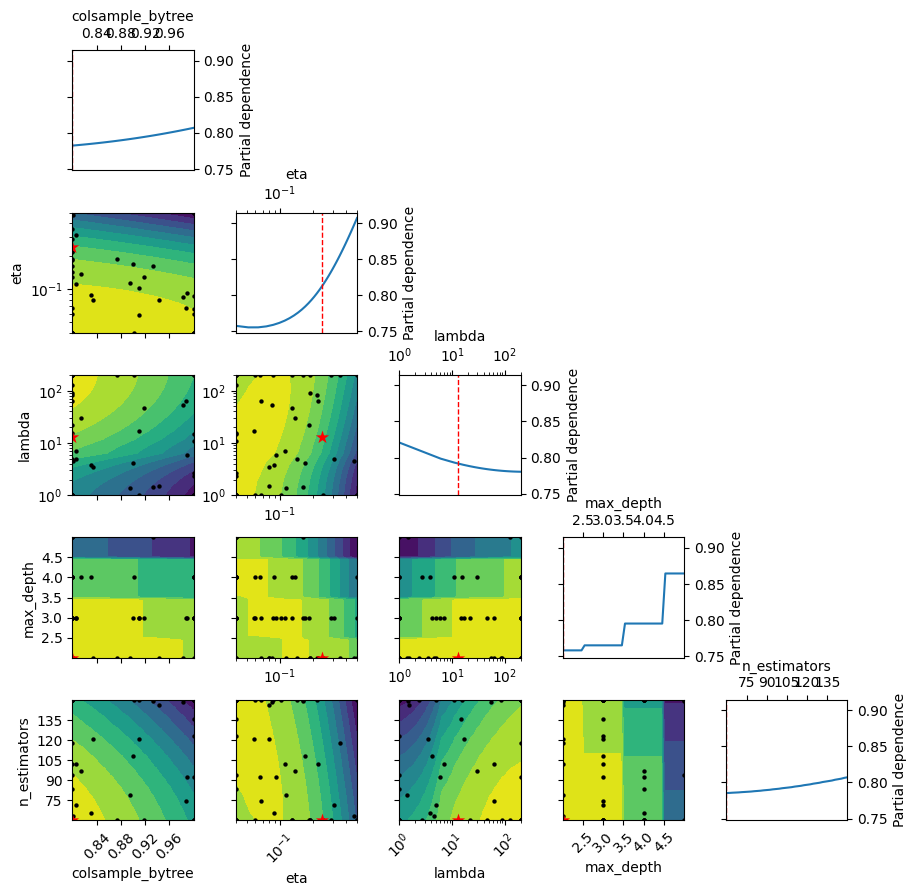

In [38]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(60,150),
    "eta": Real(0.04, 0.5, prior="log-uniform"),
    "max_depth": Integer(2,5),
    "lambda": Real(1, 200, prior="log-uniform"),
    # "alpha": Real(0.1, 10, prior="log-uniform"),
    # "gamma": Real(30,60),
    "colsample_bytree": Real(0.8,1)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=2m
# ('colsample_bytree', 0.8), ('eta', 0.24287104327930784), ('lambda', 12.948120669877431), ('max_depth', 2), ('n_estimators', 60)]) Score:  0.7376910970607561

##### Sixth Optimization

Best: OrderedDict([('colsample_bytree', 0.6152234936288836), ('eta', 0.06635892660220385), ('lambda', 24.618212424557317), ('max_depth', 4), ('n_estimators', 102)]) Score:  0.7360961738445698


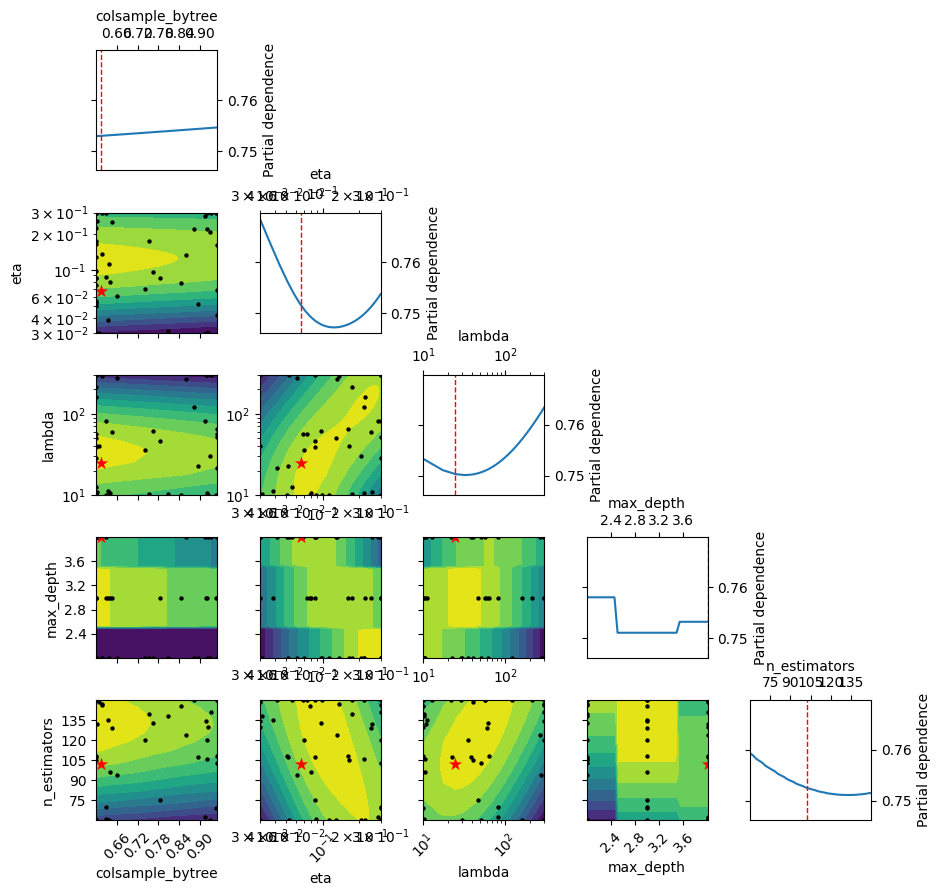

In [39]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(60,150),
    "eta": Real(0.03, 0.3, prior="log-uniform"),
    "max_depth": Integer(2,4),
    "lambda": Real(10, 300, prior="log-uniform"),
    # "alpha": Real(0.1, 10, prior="log-uniform"),
    # "gamma": Real(30,60),
    "colsample_bytree": Real(0.6,0.95)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=2m
# ('colsample_bytree', 0.6152234936288836), ('eta', 0.06635892660220385), ('lambda', 24.618212424557317), ('max_depth', 4), ('n_estimators', 102)]) Score:  0.7360961738445698

#### GridCV

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best: {'colsample_bytree': 1, 'eta': 0.3, 'lambda': 30, 'max_depth': 2, 'n_estimators': 100} Score:  0.7363585479052885


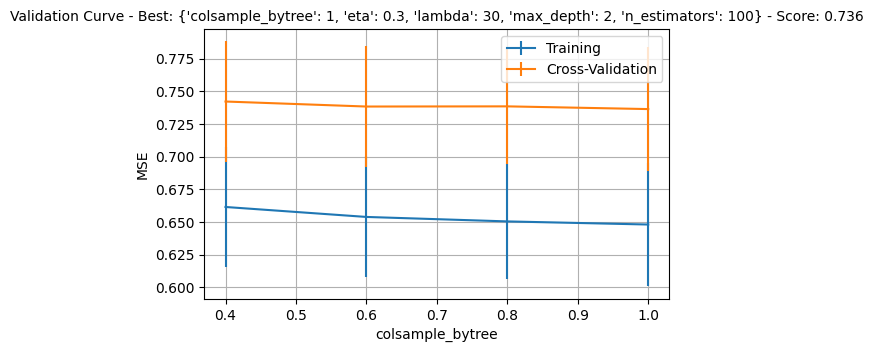

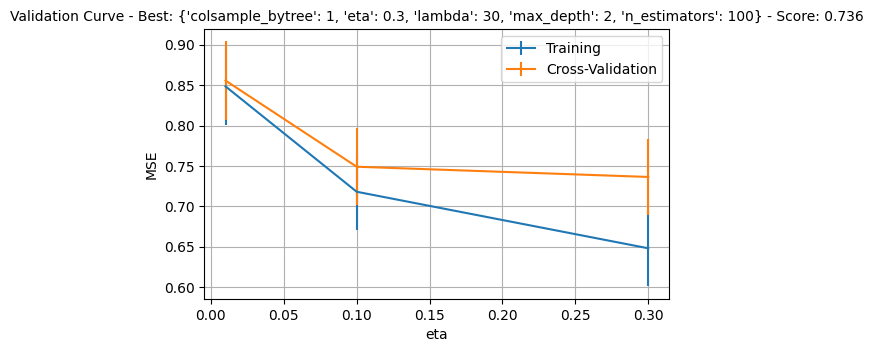

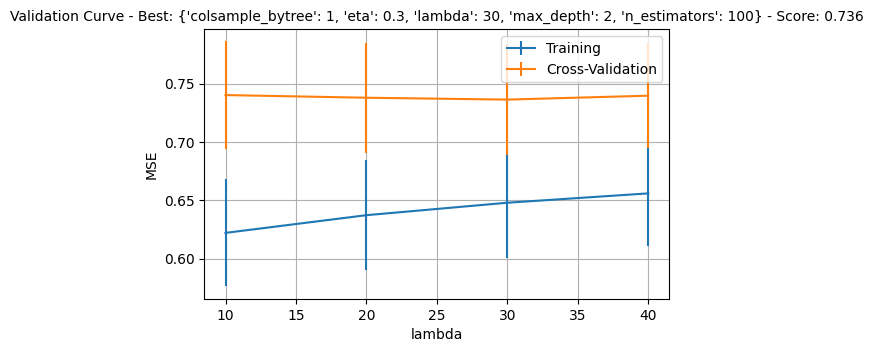

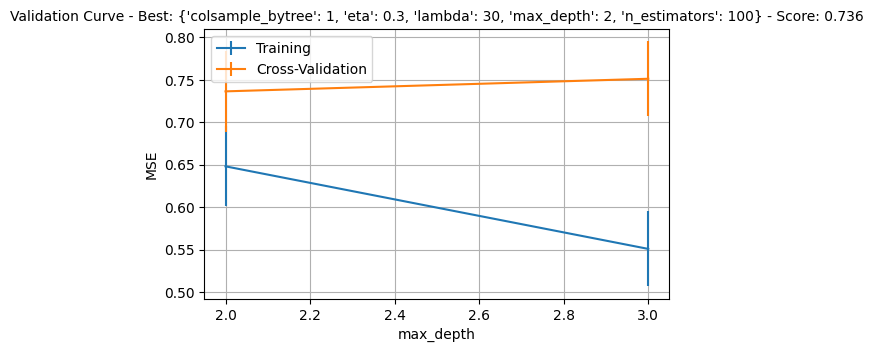

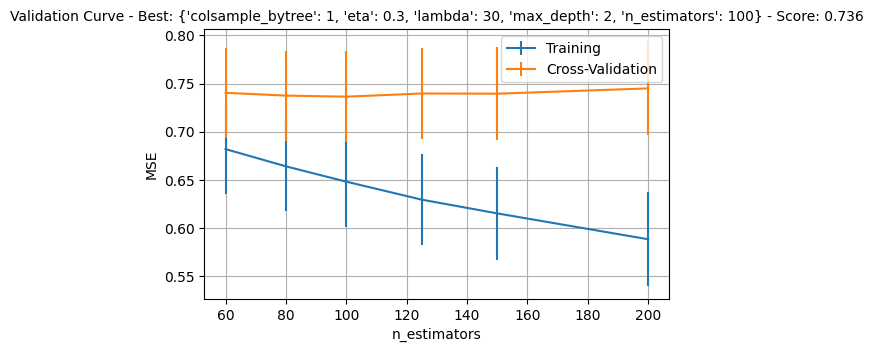

In [40]:
cv=5
grid_params = {
    "n_estimators": [60,80,100, 125, 150, 200],
    "eta": [0.01, 0.1, 0.3],
    "max_depth": [2,3],
    "lambda": [10, 20, 30, 40],
    "colsample_bytree": [0.4, 0.6, 0.8, 1],
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV3=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=m
# 

## Best Model Performance - With Outliers

#### Calculate Performance

In [ ]:
# Parameters
alpha= 0.01
eta = 0.2
lambda_par = 0.01
max_depth = 2
n_estimators = 80 

# Create model
best_xgbdt = XGBRegressor(alpha = alpha,
                     eta = eta,
                     reg_lambda = lambda_par,
                     max_depth = max_depth,
                     n_estimators = 80,
                     objective ="reg:squarederror",
                     device="cpu", 
                     multi_strategy="multi_output_tree", 
                     seed=42)

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False)
    }

# Fit model, this time on whole training data
best_xgbdt.fit(X=X_train, y=y_train)
best_model = best_xgbdt

y_test_pred = best_model.predict(X_test)

print("Best model: ", evaluate(y_test_pred, y_test))

# Final Score: 
# 'MSE': 0.6466009283176826


Best model:  {'MAE': 0.2519606889533586, 'MSE': 0.6466009283176826, 'RMSE': 0.7951185226000482}


In [ ]:
joblib.dump(best_model, "BestModels/GBDT.pkl")


['BestModels/GBDT.pkl']

#### Visualize Model Performance:

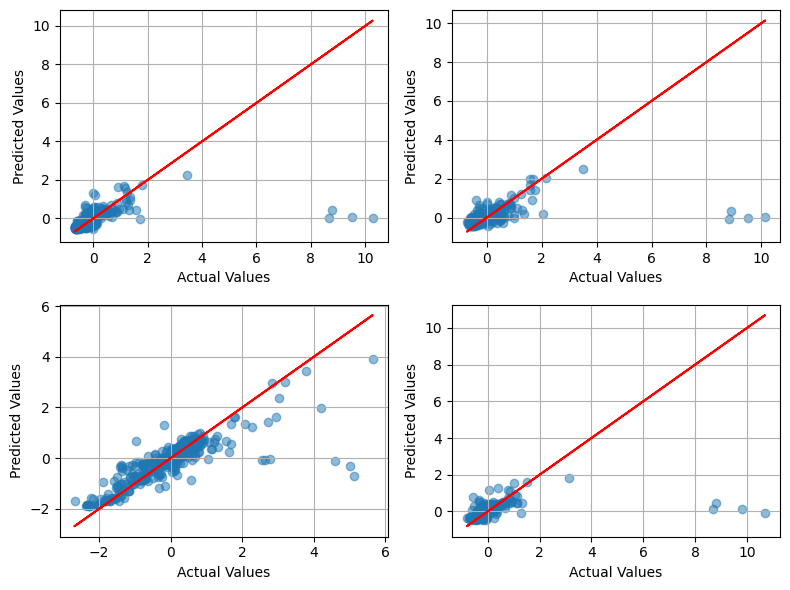

In [ ]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)
plt.tight_layout()
plt.show()

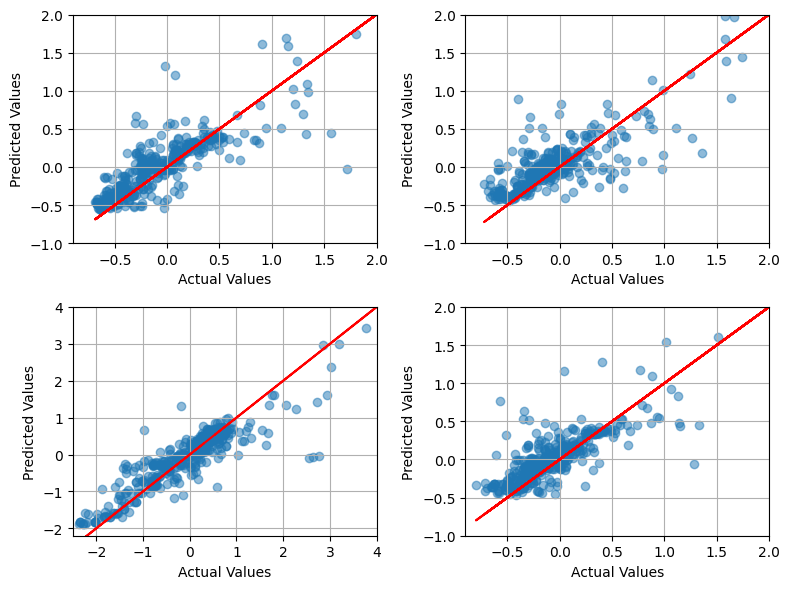

In [ ]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    if(i==2): 
        ax.set_xlim(-2.5,4)
        ax.set_ylim(-2.2,4)
    else: 
        ax.set_xlim(-0.9,2)
        ax.set_ylim(-1,2)
    ax.grid(True)
plt.tight_layout()
plt.show()

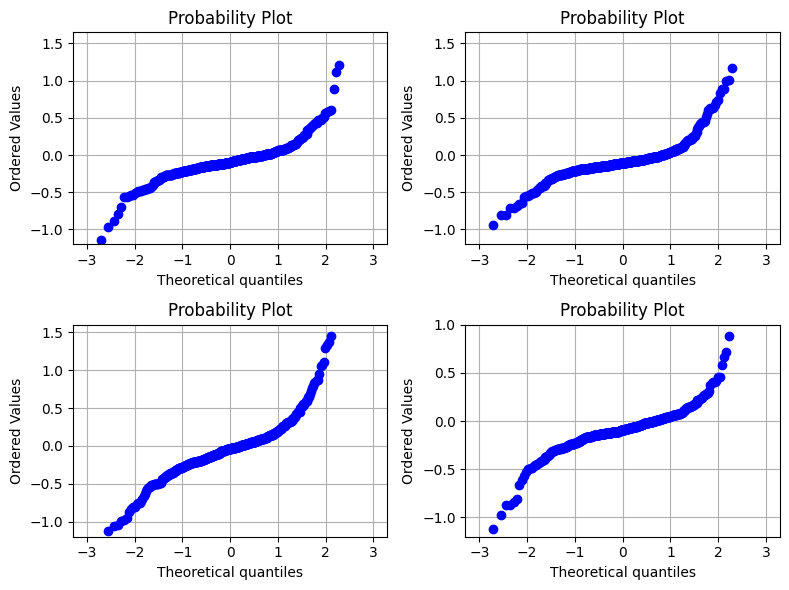

In [ ]:
# Normal probability plot
y_test_error=y_test-y_test_pred
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    _ = sp.stats.probplot(y_test_error[column], dist="norm",plot = ax, fit=False)
    if(i==2): ax.set_ylim(-1.2, 1.6)
    elif(i==3): ax.set_ylim(-1.2, 1.)
    else: ax.set_ylim(-1.2, 1.65)
    ax.grid(True)
plt.tight_layout()
plt.show()

#### Calculate Performance

In [3]:
# Parameters
alpha= 0.01
eta = 0.2
lambda_par = 0.01
max_depth = 2
n_estimators = 80 

# Create model
best_xgbdt = XGBRegressor(alpha = alpha,
                     eta = eta,
                     reg_lambda = lambda_par,
                     max_depth = max_depth,
                     n_estimators = 80,
                     objective ="reg:squarederror",
                     device="cpu", 
                     multi_strategy="multi_output_tree", 
                     seed=42)

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False)
    }

# Fit model, this time on whole training data
best_xgbdt.fit(X=X_train, y=y_train)
best_model = best_xgbdt

y_test_pred = best_model.predict(X_test)

print("Best model: ", evaluate(y_test_pred, y_test))

# Final Score: 
# 'MSE': 0.6466009283176826


Best model:  {'MAE': 0.2519606889533586, 'MSE': 0.6466009283176826, 'RMSE': 0.7951185226000482}


In [45]:
joblib.dump(best_model, "BestModels/GBDT.pkl")


['BestModels/GBDT.pkl']

#### Visualize Model Performance:

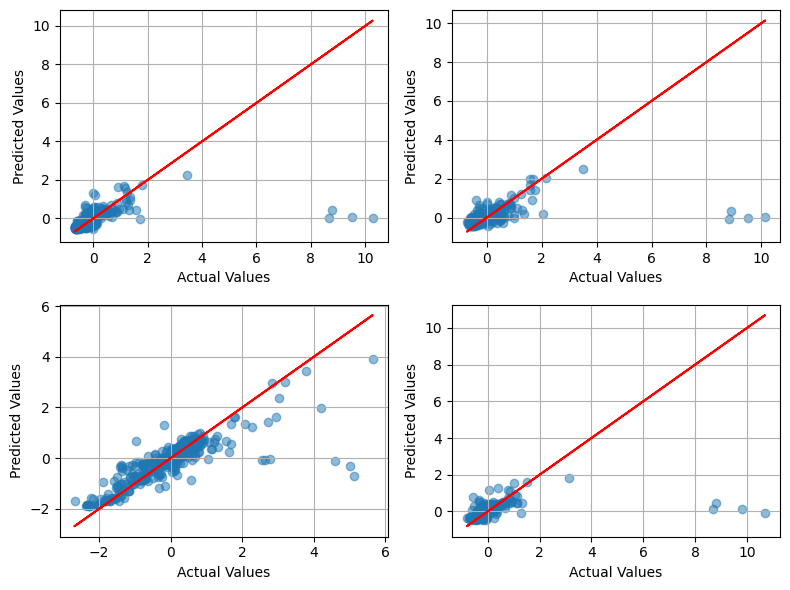

In [49]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)
plt.tight_layout()
plt.show()

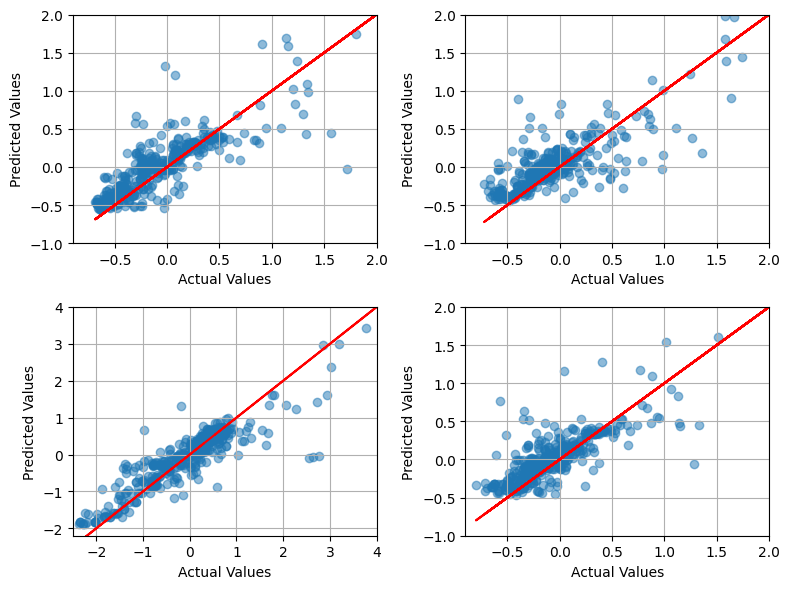

In [50]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    if(i==2): 
        ax.set_xlim(-2.5,4)
        ax.set_ylim(-2.2,4)
    else: 
        ax.set_xlim(-0.9,2)
        ax.set_ylim(-1,2)
    ax.grid(True)
plt.tight_layout()
plt.show()

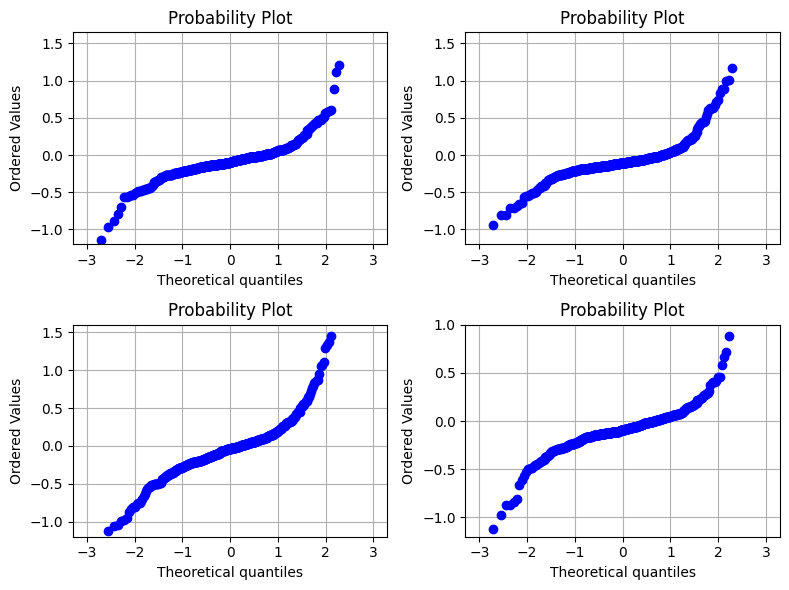

In [51]:
# Normal probability plot
y_test_error=y_test-y_test_pred
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    _ = sp.stats.probplot(y_test_error[column], dist="norm",plot = ax, fit=False)
    if(i==2): ax.set_ylim(-1.2, 1.6)
    elif(i==3): ax.set_ylim(-1.2, 1.)
    else: ax.set_ylim(-1.2, 1.65)
    ax.grid(True)
plt.tight_layout()
plt.show()

## Model Selection - Without Outliers

### Function Definitions

In [5]:
def plotValidationCurve1D(gs):
    # Create validation plot around best parameter choice by keeping all but one parameter value constant
    # Select first non-constant parameter and obtain dictionary of all other parameters
    for key, value in gs.best_params_.items():
        other_items = gs.best_params_.copy()
        other_items.pop(key)
        
        #collect indices of all other parameters which are suposed to stay constant 
        indices = []
        if (len(other_items)==0): indices = [(i, item) in enumerate(gs.cv_results_["params"])]
        else:
            for i, item in enumerate(gs.cv_results_["params"]):
                match = True
                for condition_key, condition_value in other_items.items():
                    if(item[condition_key]!=condition_value):
                        match = False
                        break
                if(match==True):indices.append((i, item))  
        
        #select relevant datapoints from train/test scores
        x_axis, train_scores, train_std, test_scores, test_std = [],[],[],[],[]
        for i, item in indices:
            x_axis.append(item[key])
            train_scores.append(-gs.cv_results_["mean_train_score"][i])
            train_std.append(gs.cv_results_["std_train_score"][i])
            test_scores.append(-gs.cv_results_["mean_test_score"][i])
            test_std.append(gs.cv_results_["std_test_score"][i])

        #plot with correct labeling 
        if(len(x_axis)>1): 
            fig = plt.figure(figsize=(6,3.5))
            plt.errorbar(x=x_axis,y=train_scores, yerr= train_std, label = "Training")
            plt.errorbar(x=x_axis,y=test_scores, yerr = train_std, label = "Cross-Validation")
            plt.xlabel(key)
            plt.ylabel("MSE")
            plt.title(f"Validation Curve - Best: {gs.best_params_} - Score: {-gs.best_score_:.3f}", fontsize=10)
            plt.grid(True)
            plt.legend()
            plt.show()
    
# Conduct hyperparameter CV search with different search and fitting strategies 
def crossvalidateXGBDT(grid_parameters, cv, multi_strategy, search_strategy):
    n_cpus = os.cpu_count()-1
    kf=KFold(n_splits=cv, shuffle = True, random_state=42)

    # for multi-output => on cpu, for one output => on gpu
    if (multi_strategy=="multi_output_tree"): xgbdt = XGBRegressor(objective ="reg:squarederror", device="cpu", multi_strategy="multi_output_tree", seed=42)
    elif (multi_strategy=="one_output_per_tree"): xgbdt = XGBRegressor(objective ="reg:squarederror", device="cpu", multi_strategy="one_output_per_tree", seed=42)
    else: raise Exception("No valid multi strategy entered")
    
    if(search_strategy == "GridCV"):
        gs = GridSearchCV(
            estimator = xgbdt,
            param_grid = grid_params,
            cv = kf,
            n_jobs = n_cpus,
            scoring = "neg_mean_squared_error",
            verbose = 1,
            return_train_score = True
        )    
    elif(search_strategy == "Bayesian"):
        gs = BayesSearchCV(
            estimator = xgbdt,
            search_spaces = grid_params,
            cv = kf,
            n_jobs = n_cpus,
            n_iter = n_iter,
            scoring = "neg_mean_squared_error",
            verbose = 0,
            return_train_score = True
        )    
    else: raise Exception("No valid search strategy entered")

    # Plot Results:
    xgbdt_gs = gs.fit(X_train, y_train)
    print("Best:", xgbdt_gs.best_params_, "Score: ", -xgbdt_gs.best_score_)
    if(search_strategy == "GridCV"): plotValidationCurve1D(gs=xgbdt_gs)   
    else: _ = plot_objective(xgbdt_gs.optimizer_results_[0])
    
    return xgbdt_gs.best_estimator_

### Multi-Output-Tree

#### Basic Parameters

##### First Optimization

Best: OrderedDict([('alpha', 0.01), ('eta', 0.3073760822133791), ('lambda', 0.01), ('max_depth', 5), ('n_estimators', 100)]) Score:  0.026090062917024585


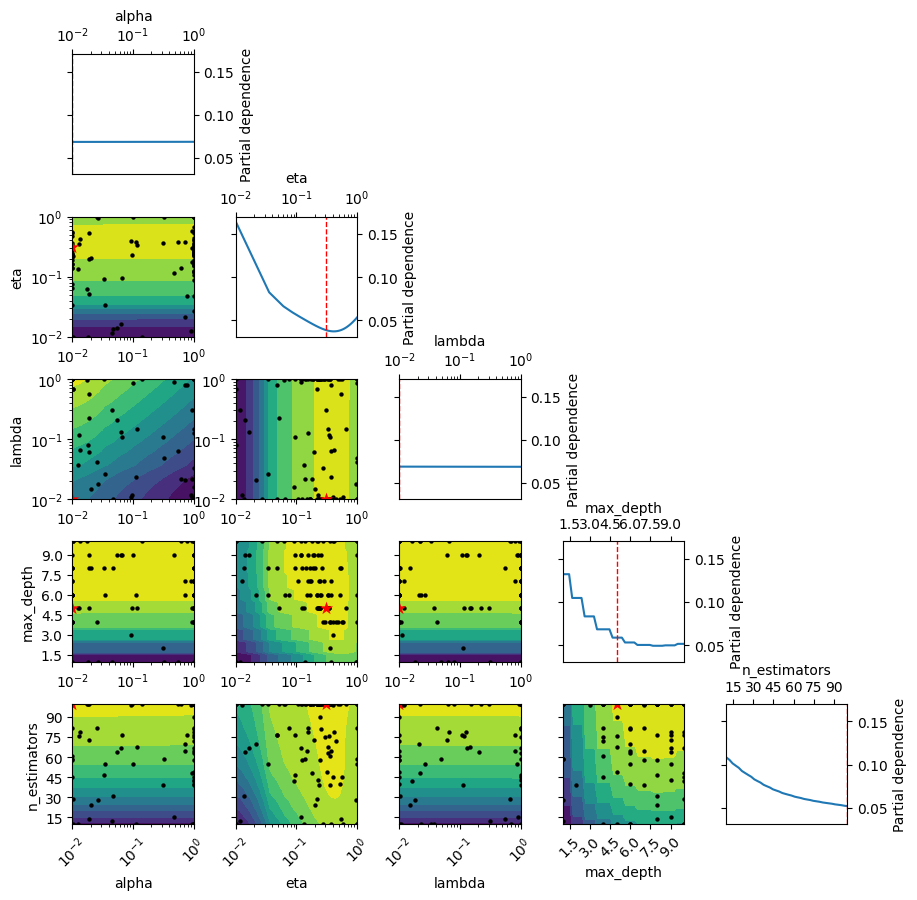

In [9]:
#Hyperparameters:
cv=5
n_iter=100
grid_params = {
    "n_estimators": Integer(10,100),
    "eta": Real(0.01, 1, prior="log-uniform"),
    "max_depth": Integer(1,10),
    "lambda": Real(0.01, 1, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform")
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=12m42s
# ('alpha', 0.01), ('eta', 0.3073760822133791), ('lambda', 0.01), ('max_depth', 5), ('n_estimators', 100)]) Score:  0.026090062917024585

##### Second Optimization

Fitting 3 folds for each of 1350 candidates, totalling 4050 fits


Best: {'alpha': 0.01, 'eta': 0.2, 'lambda': 1, 'max_depth': 5, 'n_estimators': 150} Score:  0.02665214522324159


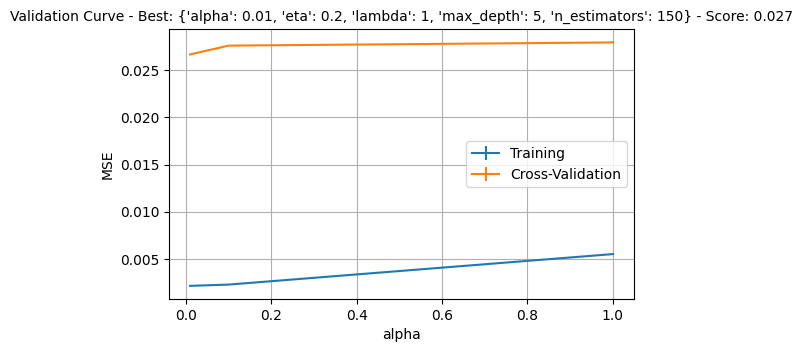

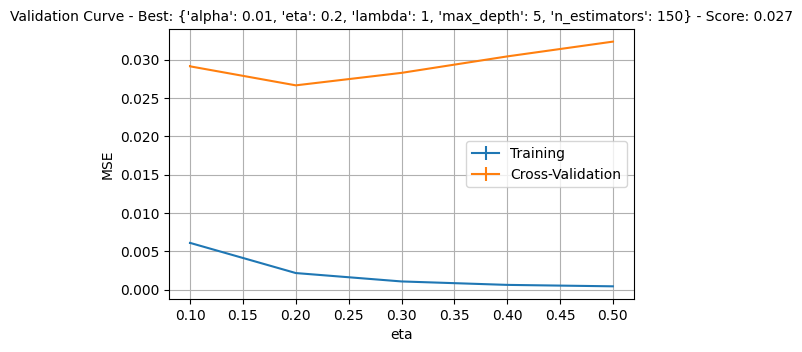

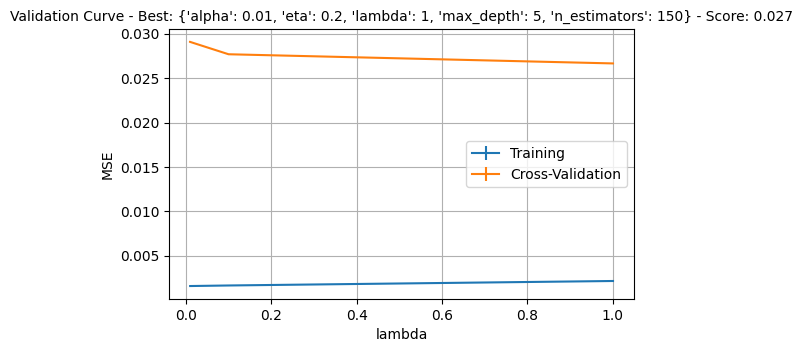

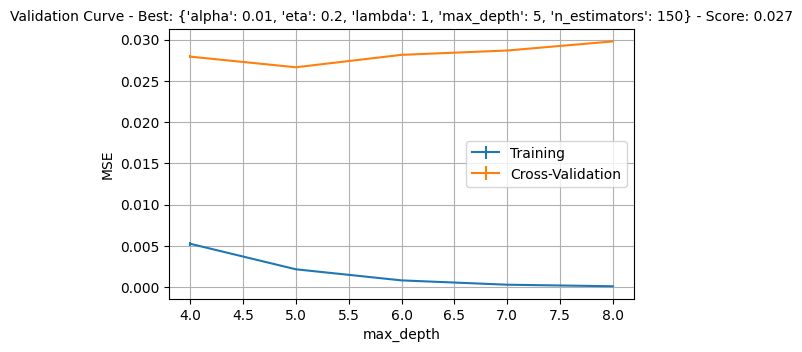

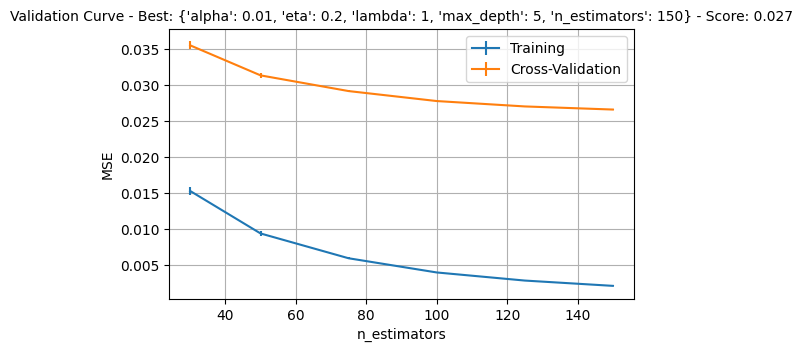

In [11]:
#Hyperparameters:
cv=3
grid_params = {
    "n_estimators": [30,50,75,100,125,150],
    "eta": [0.1,0.2,0.3,0.4,0.5],
    "max_depth": [4,5,6,7,8],
    "lambda": [0.01, 0.1, 1],
    "alpha": [0.01, 0.1, 1],
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=40m38s
# {'alpha': 0.01, 'eta': 0.2, 'lambda': 1, 'max_depth': 5, 'n_estimators': 150} Score:  0.02665214522324159

##### Third Optimization

Fitting 3 folds for each of 180 candidates, totalling 540 fits
Best: {'eta': 0.2, 'lambda': 1, 'max_depth': 5, 'n_estimators': 250} Score:  0.02550252726897424


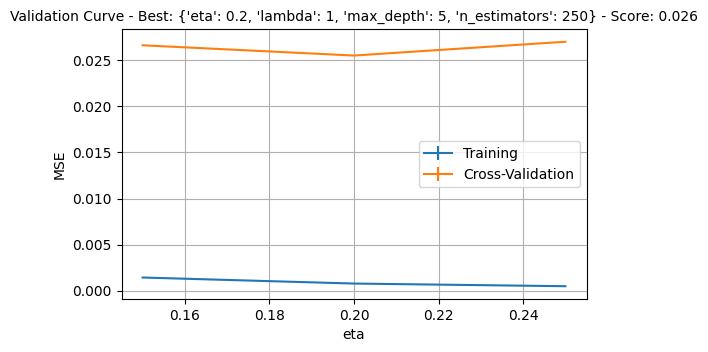

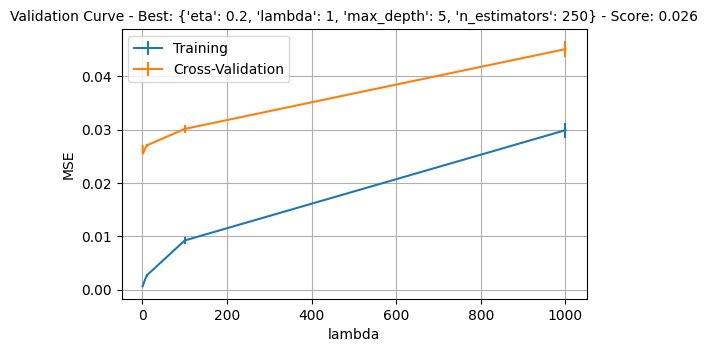

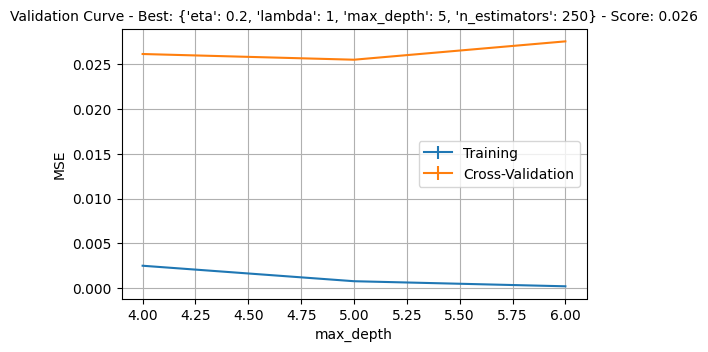

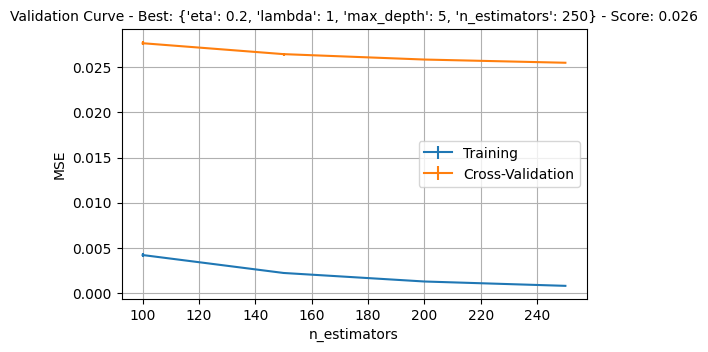

In [12]:
#Hyperparameters:
cv=3
grid_params = {
    "n_estimators": [100,150,200,250],
    "eta": [0.15,0.2,0.25],
    "max_depth": [4,5,6],
    "lambda": [0.5, 1, 10, 100, 1000],
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=4m46s
# {'eta': 0.2, 'lambda': 1, 'max_depth': 5, 'n_estimators': 250} Score:  0.02550252726897424

##### Fourth Optimization

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best: {'eta': 0.2, 'lambda': 0.5, 'max_depth': 4, 'n_estimators': 500} Score:  0.02203964525333681


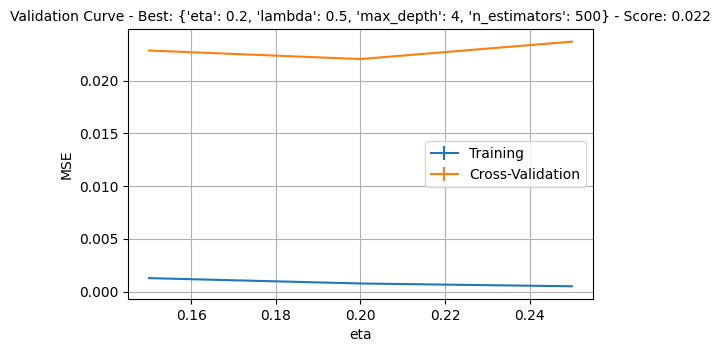

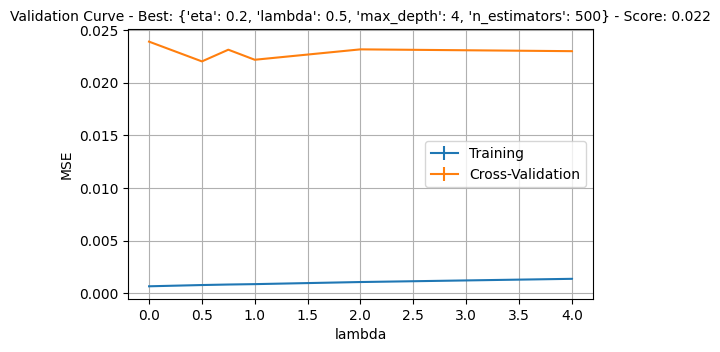

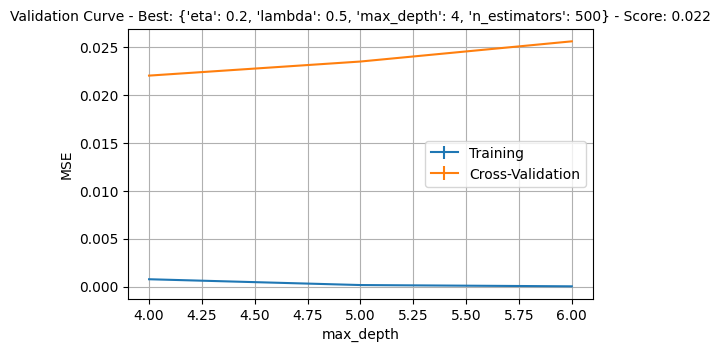

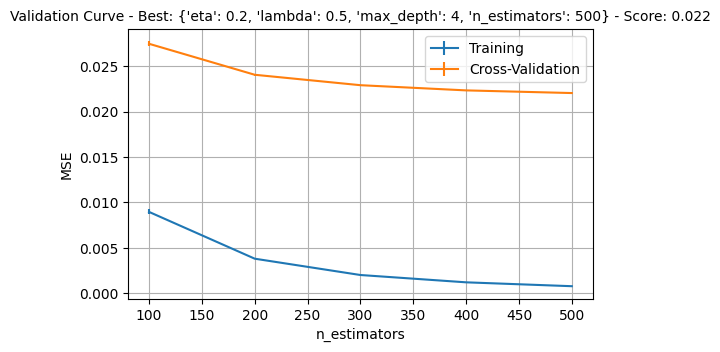

In [14]:
#Hyperparameters:
cv=5
grid_params = {
    "n_estimators": [100,200,300,400,500],
    "eta": [0.15,0.2,0.25],
    "max_depth": [4,5,6],
    "lambda": [0, 0.5, 0.75, 1, 2, 4],
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=4m46s
# {'eta': 0.2, 'lambda': 0.5, 'max_depth': 4, 'n_estimators': 500} Score:  0.02203964525333681

##### Fifth Optimization

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best: {'eta': 0.2, 'lambda': 0.5, 'max_depth': 4, 'n_estimators': 1000} Score:  0.02150053976571792


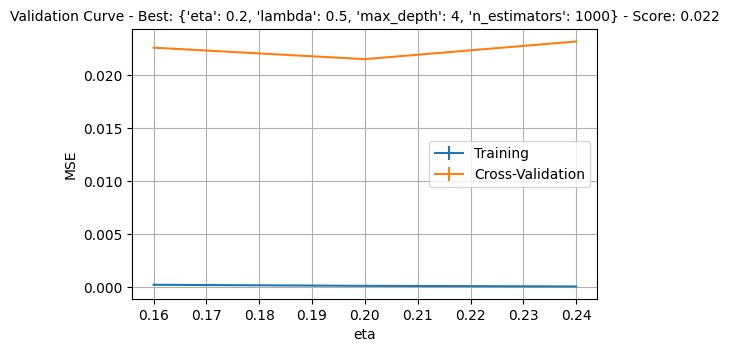

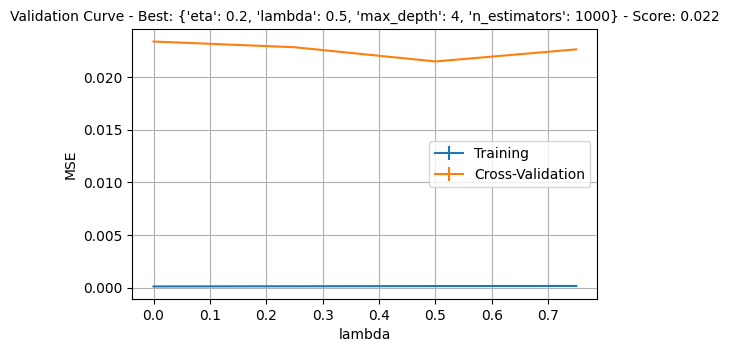

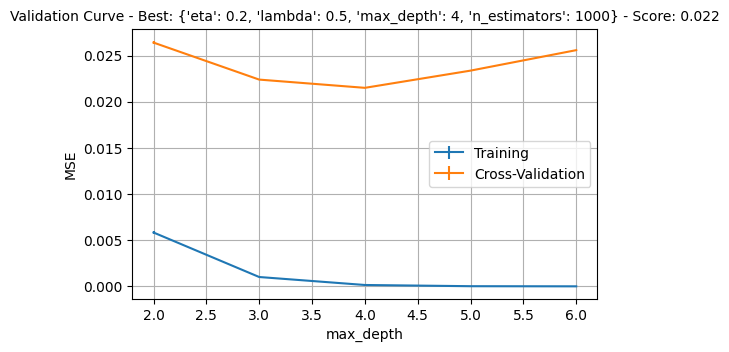

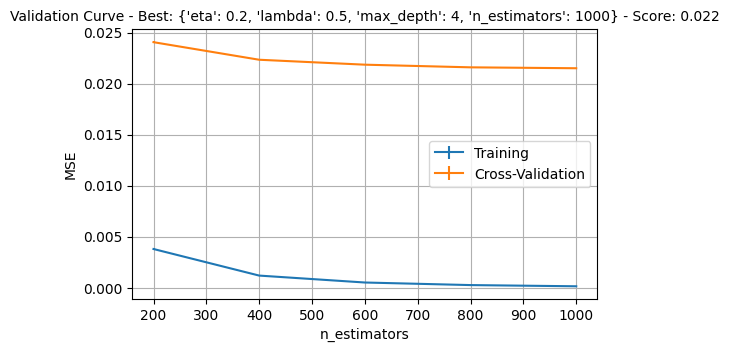

In [16]:
#Hyperparameters:
cv=5
grid_params = {
    "n_estimators": [200,400,600,800,1000],
    "eta": [0.16,0.2,0.24],
    "max_depth": [2,3,4,5,6],
    "lambda": [0, 0.25, 0.5, 0.75],
    
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bytree": [1],
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=31m12s
# {'eta': 0.2, 'lambda': 0.5, 'max_depth': 4, 'n_estimators': 1000} Score:  0.02150053976571792

#### Advanced Parameters

##### First Optimization

Best: OrderedDict([('alpha', 1.0), ('colsample_bytree', 1.0), ('eta', 0.19073156753310502), ('gamma', 0.0), ('lambda', 1.723173238792663), ('max_depth', 6), ('n_estimators', 100), ('subsample', 1.0)]) Score:  0.02877967910202084


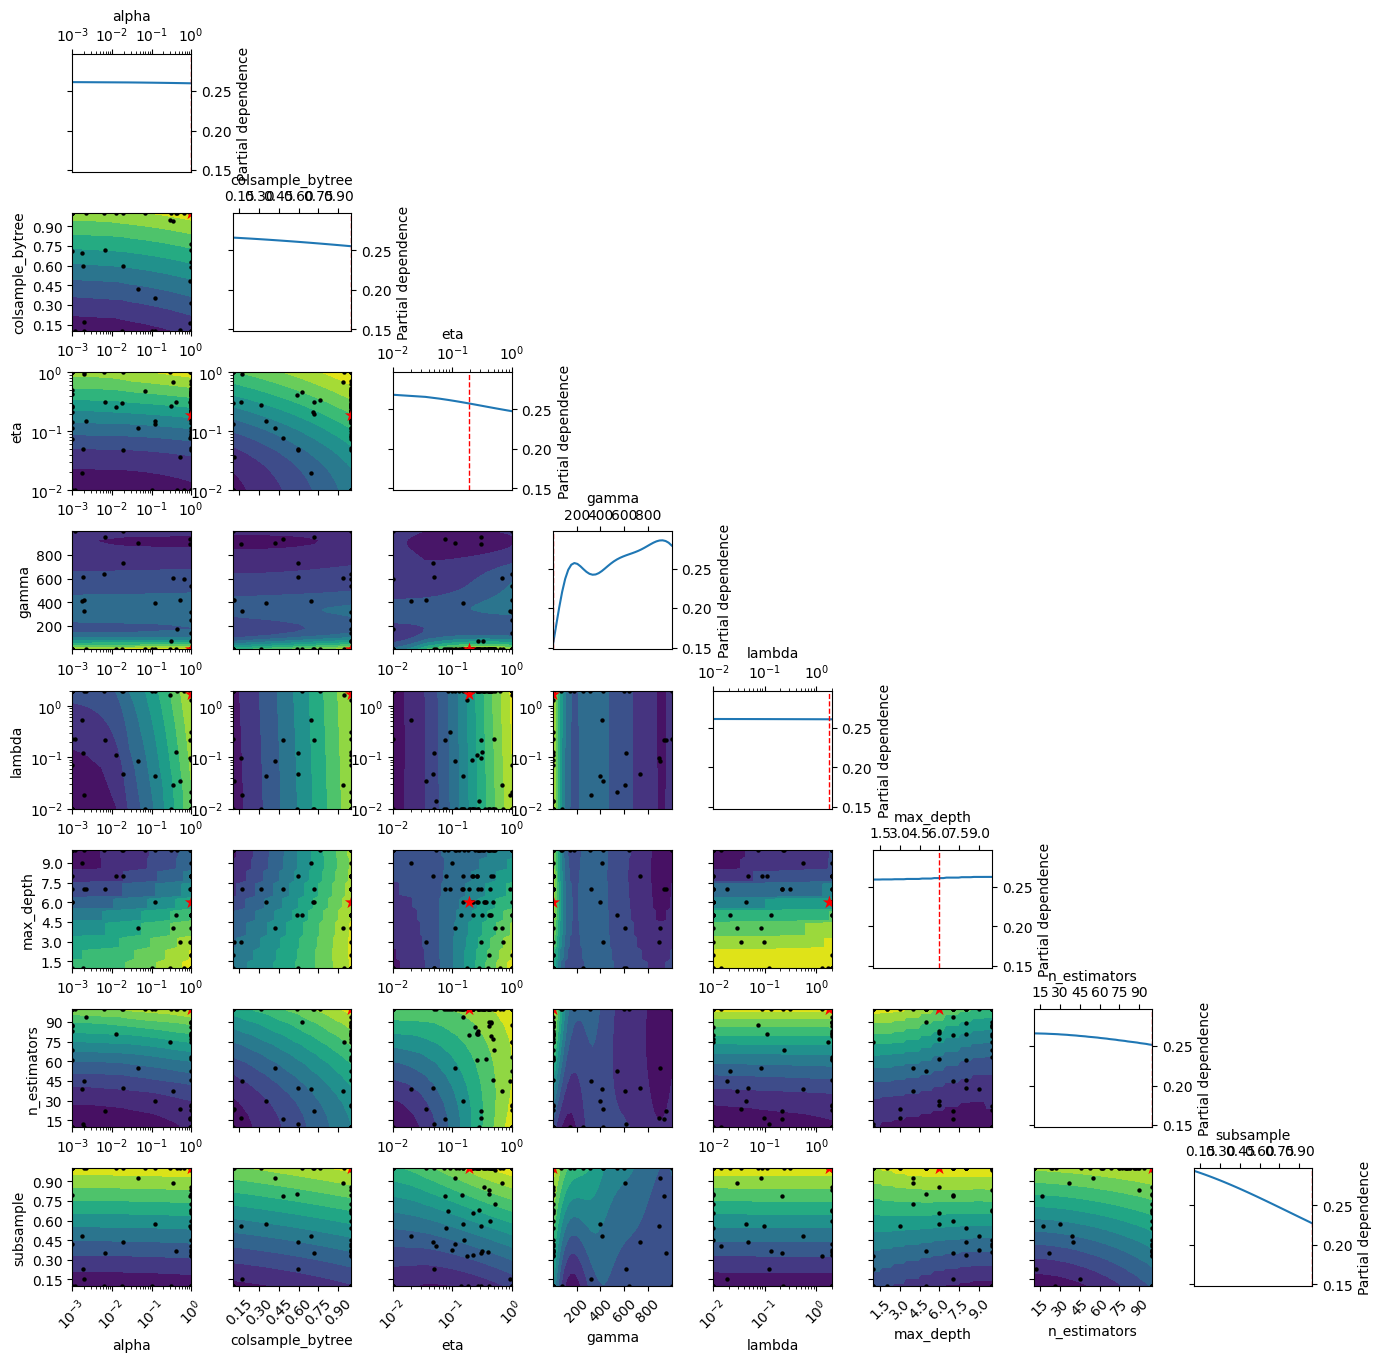

In [17]:
#Hyperparameters:
cv=3
n_iter=100
grid_params = {
    "n_estimators": Integer(10,100),
    "eta": Real(0.01, 1, prior="log-uniform"),
    "max_depth": Integer(1,10),
    "lambda": Real(0.01, 2, prior="log-uniform"),
    "alpha": Real(0.001, 1, prior="log-uniform"),
    "gamma": Real(0,1000),
    "subsample": Real(0.1,1),
    "colsample_bytree": Real(0.1,1)
    # # Other options:
    # "min_split_loss": [0],
    # "min_child_weight": [1],
    # "max_delta_step": [0],
    # "subsample": [1],
    # "max_leaves": [0],
    # "max_bin": [256],
    # #following work cumulatively:
    # "colsample_bylevel": [1],
    # "colsample_bynode": [1]
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=12m
# ('alpha', 1.0), ('colsample_bytree', 1.0), ('eta', 0.19073156753310502), ('gamma', 0.0), ('lambda', 1.723173238792663), ('max_depth', 6), ('n_estimators', 100), ('subsample', 1.0)]) Score:  0.02877967910202084

##### Second Optimization
Everything hints at previous solution being best

Best: OrderedDict([('alpha', 0.3912008259491369), ('eta', 0.1860317026238857), ('gamma', 0.0), ('lambda', 3.0), ('max_depth', 4), ('n_estimators', 400)]) Score:  0.02518311046995182


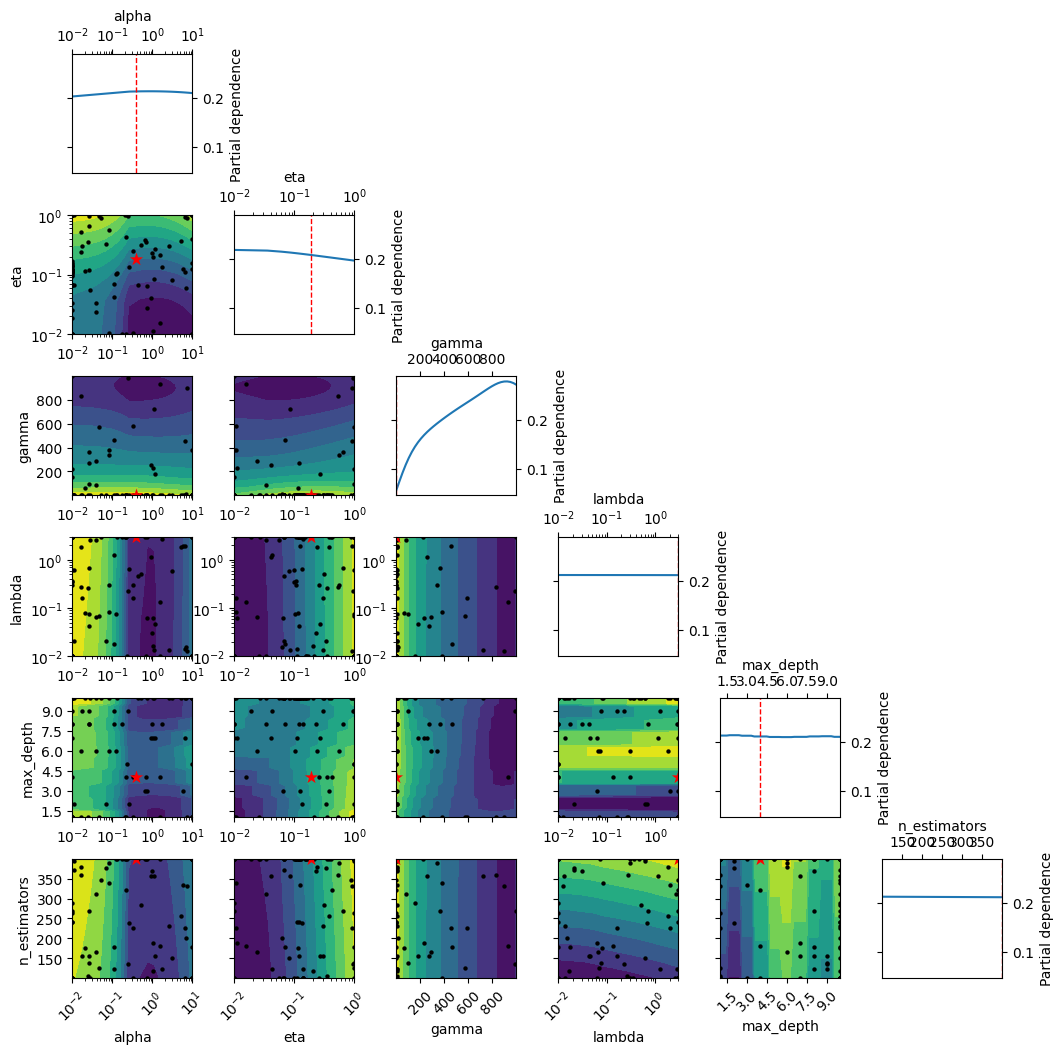

In [18]:
#Hyperparameters:
cv=3
n_iter=100
grid_params = {
    "n_estimators": Integer(100,400),
    "eta": Real(0.01, 1, prior="log-uniform"),
    "max_depth": Integer(1,10),
    "lambda": Real(0.01, 3, prior="log-uniform"),
    "alpha": Real(0.01, 10, prior="log-uniform"),
    "gamma": Real(0,1000)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=26m
# ('alpha', 0.3912008259491369), ('eta', 0.1860317026238857), ('gamma', 0.0), ('lambda', 3.0), ('max_depth', 4), ('n_estimators', 400)]) Score:  0.02518311046995182

### Single Output Per Tree

##### First Optimization

Best: OrderedDict([('alpha', 1.0), ('colsample_bytree', 1.0), ('eta', 1.0), ('gamma', 0.0), ('lambda', 3.0), ('max_depth', 8), ('n_estimators', 96), ('subsample', 1.0)]) Score:  0.044428651418740334


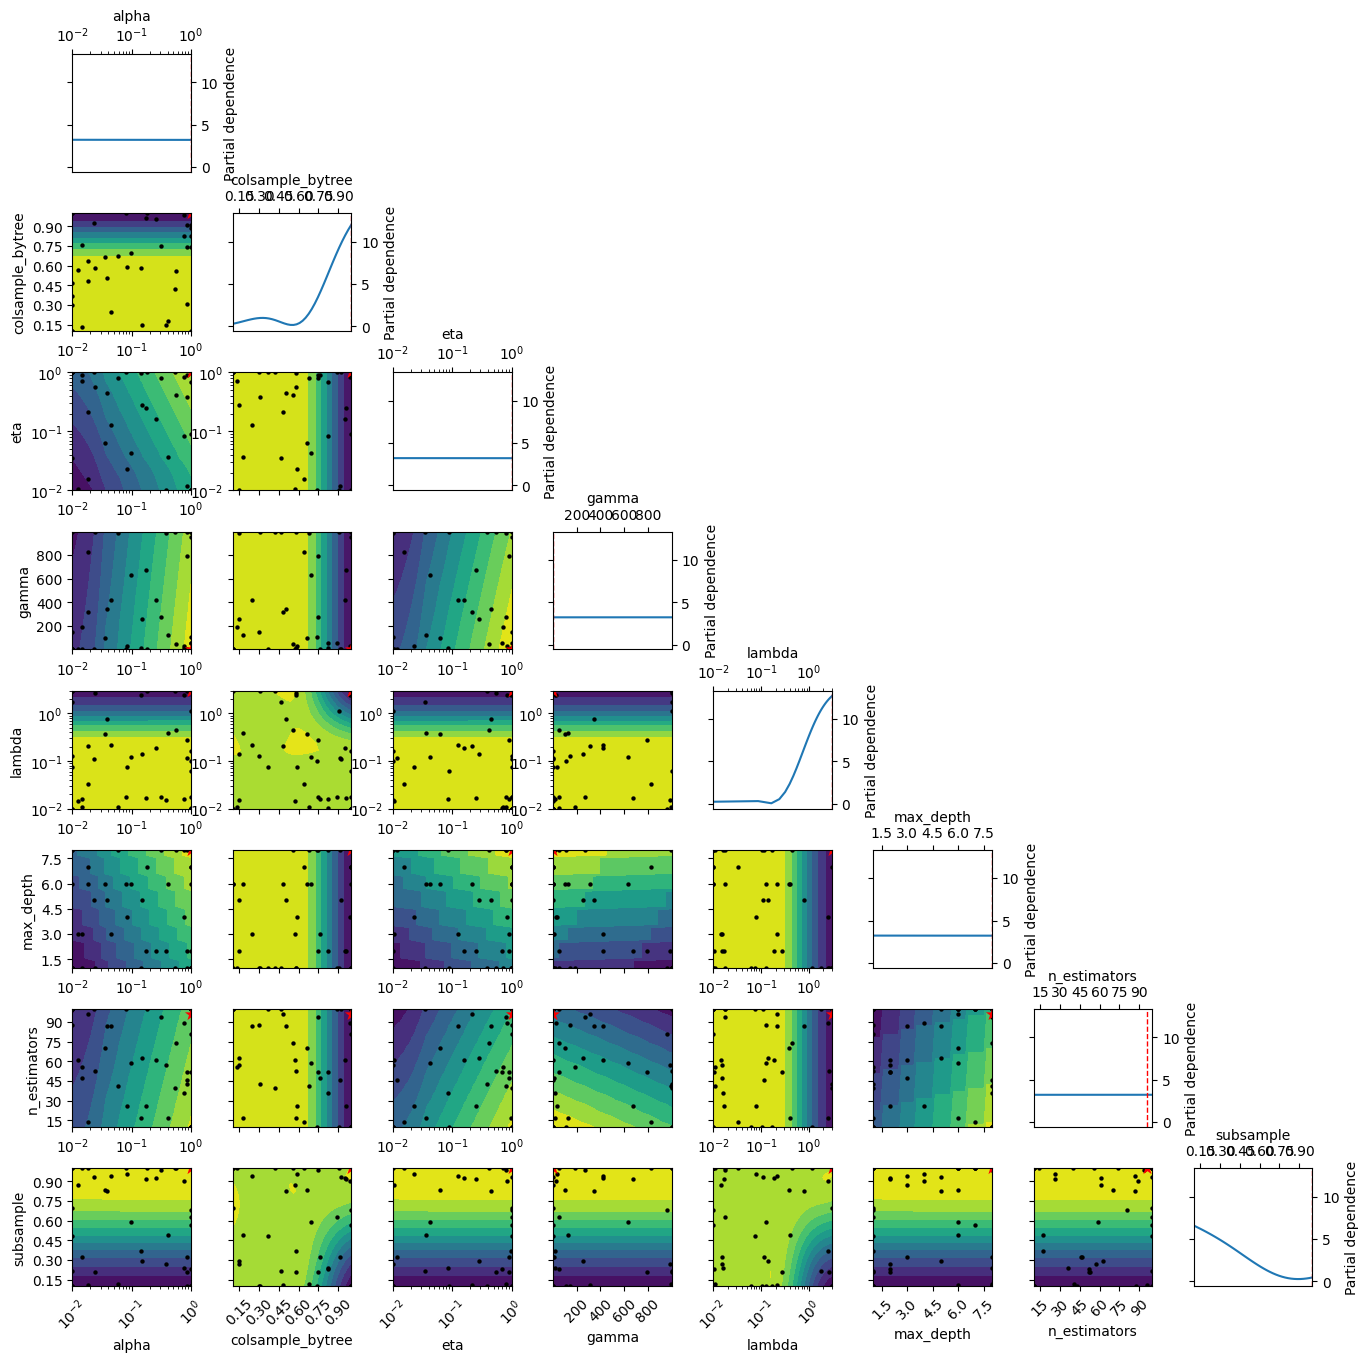

In [20]:
#Hyperparameters:
cv=3
n_iter=50
grid_params = {
    "n_estimators": Integer(10,100),
    "eta": Real(0.01, 1, prior="log-uniform"),
    "max_depth": Integer(1,8),
    "lambda": Real(0.01, 3, prior="log-uniform"),
    "alpha": Real(0.01, 1, prior="log-uniform"),
    "gamma": Real(0,1000),
    "subsample": Real(0.1,1),
    "colsample_bytree": Real(0.1,1)
}

#Evaluate Performance
best_model_CV1=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="one_output_per_tree",
    search_strategy = "Bayesian"
    )

# Best Model in t=9m
# ('alpha', 1.0), ('colsample_bytree', 1.0), ('eta', 1.0), ('gamma', 0.0), ('lambda', 3.0), ('max_depth', 8), ('n_estimators', 96), ('subsample', 1.0)]) Score:  0.044428651418740334

##### Second Optimization

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best: {'alpha': 0.1, 'eta': 0.1, 'lambda': 0.1, 'max_depth': 6, 'n_estimators': 150} Score:  0.02805688197586884


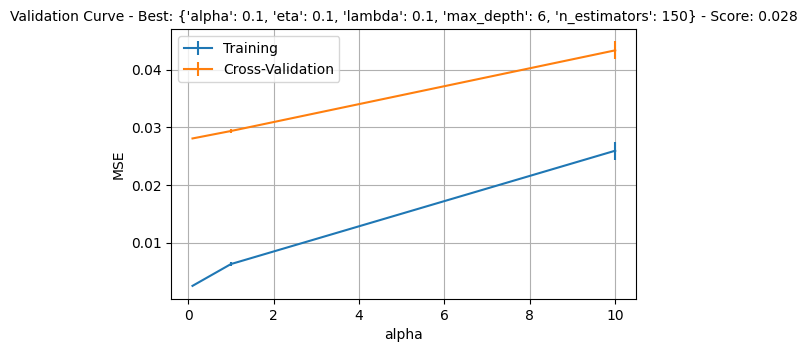

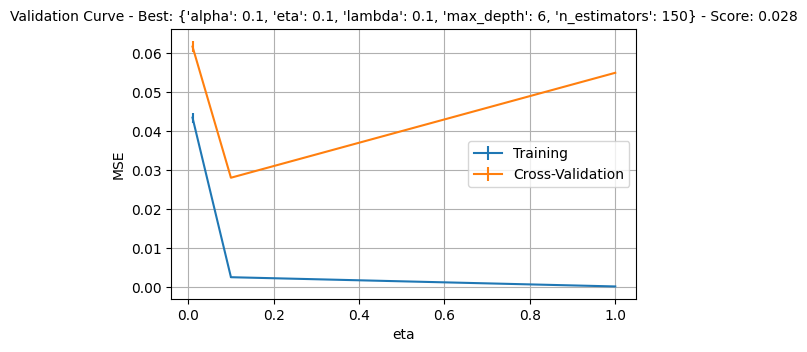

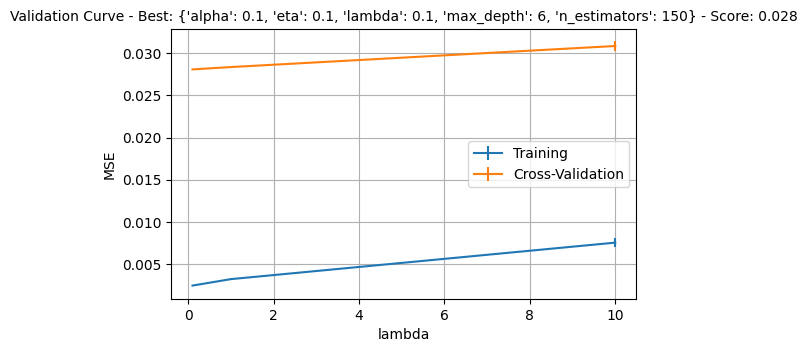

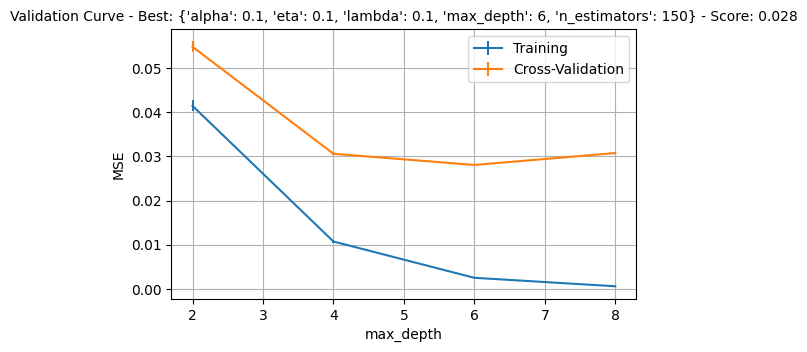

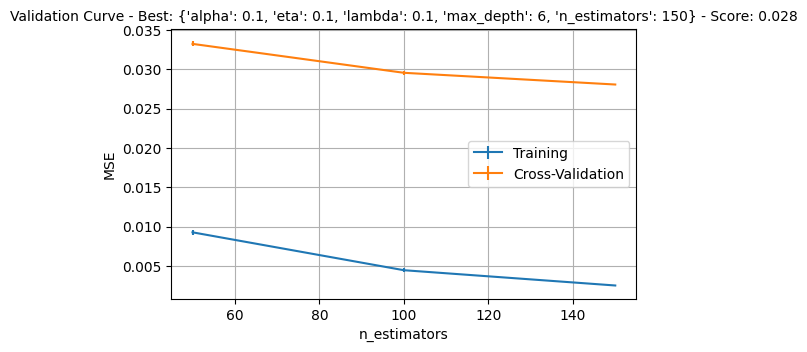

In [22]:
cv=3
grid_params = {
    "n_estimators": [50,100,150],
    "eta": [0.01,0.1,1],
    "max_depth": [2,4,6,8],
    "lambda": [0.1,1,10],
    "alpha": [0.1,1,10]
}

#Evaluate Performance
best_model_CV3=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=7.5m
# {'alpha': 0.1, 'eta': 0.1, 'lambda': 0.1, 'max_depth': 6, 'n_estimators': 150} Score:  0.02805688197586884

##### Third Optimization
Multi output tree comparable and will thus be chosen

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best: {'eta': 0.25, 'max_depth': 3, 'n_estimators': 300} Score:  0.02427034782626901


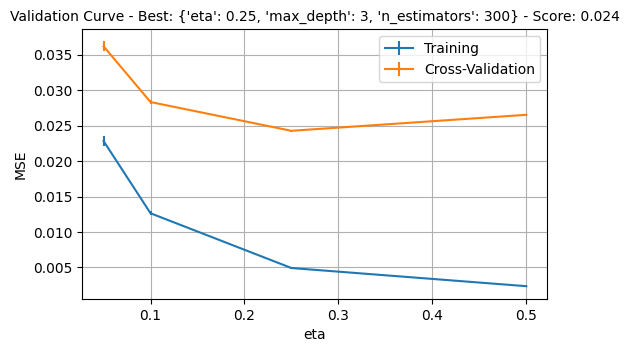

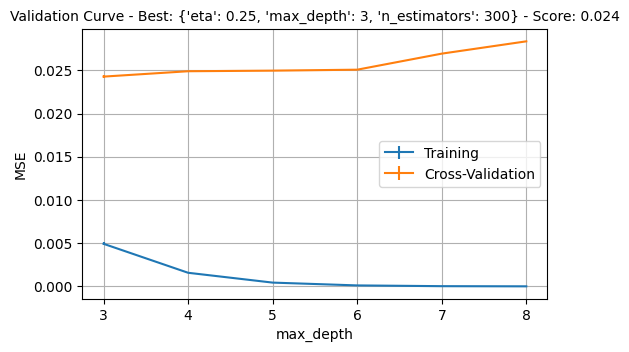

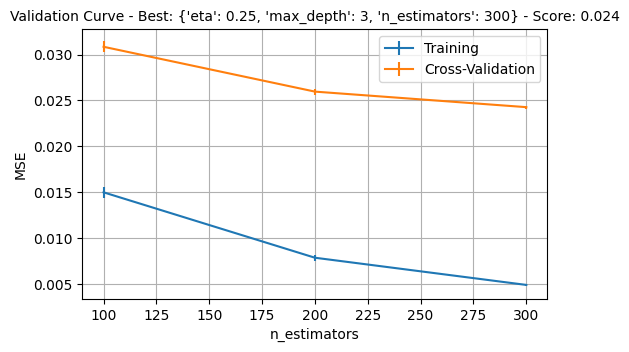

In [24]:
cv=5
grid_params = {
    "n_estimators": [100,200,300],
    "eta": [0.05,0.1,0.25,0.5],
    "max_depth": [3,4,5,6,7,8]
}

#Evaluate Performance
best_model_CV3=crossvalidateXGBDT(
    grid_parameters=grid_params, 
    cv=cv,
    multi_strategy="multi_output_tree",
    search_strategy = "GridCV"
    )

# Best Model in t=7.5m
# 

## Best Model Performance - Without Outliers

#### Calculate Performance

In [39]:
# Parameters
eta = 0.2
lambda_par = 0.5
max_depth = 4
n_estimators = 1000 

# Create model
best_xgbdt = XGBRegressor(eta = eta,
                     reg_lambda = lambda_par,
                     max_depth = max_depth,
                     n_estimators = n_estimators,
                     objective ="reg:squarederror",
                     device="cpu", 
                     multi_strategy="multi_output_tree", 
                     seed=42)

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False)
    }

# Fit model, this time on whole training data
best_xgbdt.fit(X=X_train, y=y_train)
best_model = best_xgbdt

y_test_pred = best_model.predict(X_test)

print("Best model: ", evaluate(y_test_pred, y_test))

# Final Score: 
# 'MSE': 0.02548276718563143


Best model:  {'MAE': 0.0631337258851696, 'MSE': 0.02545680402507504, 'RMSE': 0.1483070428793353}


In [40]:
joblib.dump(best_model, "BestModels/GBDT.pkl")


['BestModels/GBDT.pkl']

#### Visualize Model Performance:

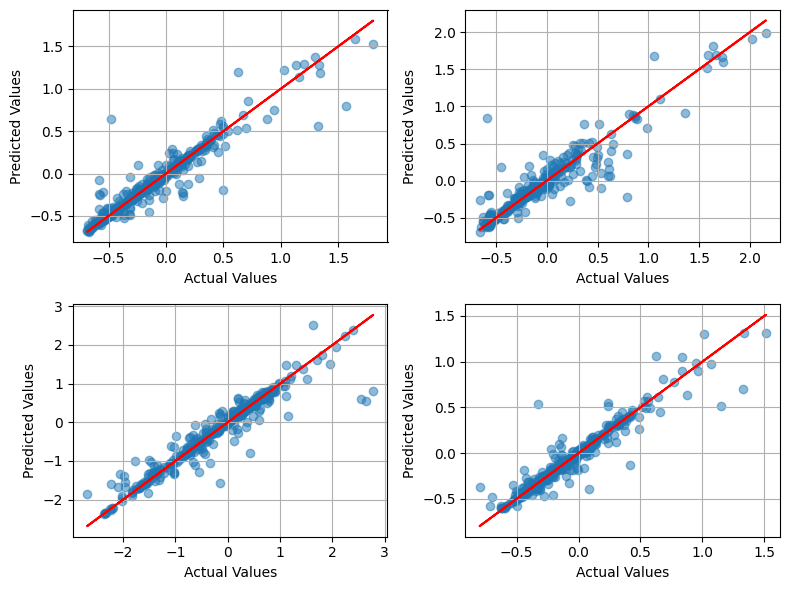

In [41]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.grid(True)
plt.tight_layout()
plt.show()

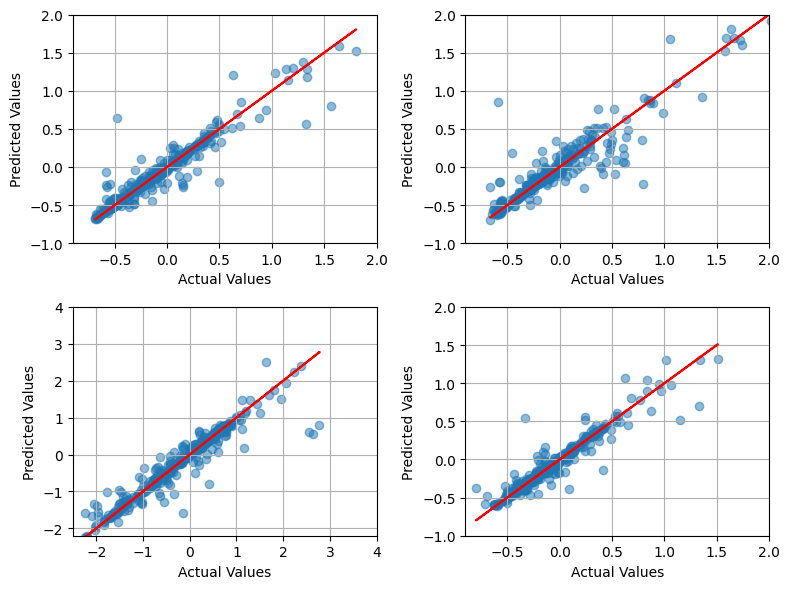

In [42]:
df_y_test_pred=pd.DataFrame(y_test_pred, columns=ycolumns)
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    ax.scatter(y_test[column], df_y_test_pred[column], alpha=0.5)
    ax.plot(y_test[column],y_test[column], color="red", linestyle = "-")
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    if(i==2): 
        ax.set_xlim(-2.5,4)
        ax.set_ylim(-2.2,4)
    else: 
        ax.set_xlim(-0.9,2)
        ax.set_ylim(-1,2)
    ax.grid(True)
plt.tight_layout()
plt.show()

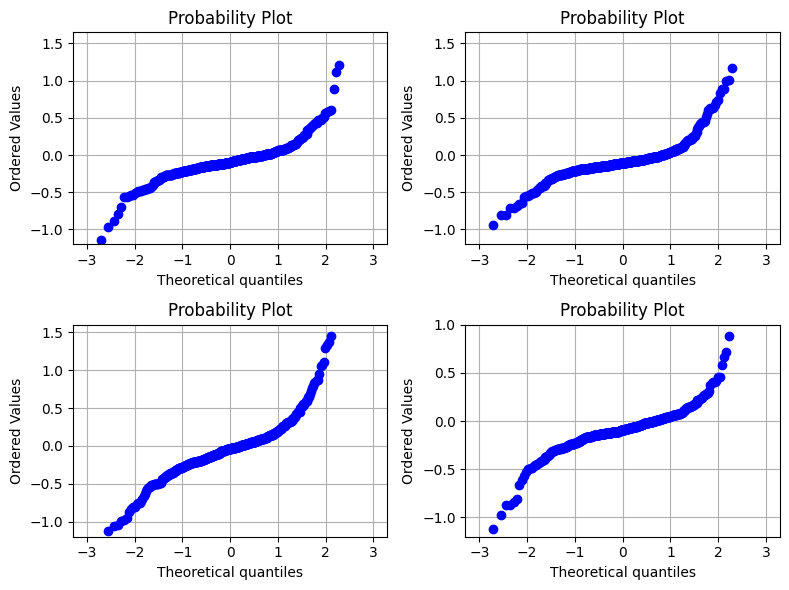

In [ ]:
# Normal probability plot
y_test_error=y_test-y_test_pred
fig, axs = plt.subplots(2, 2, figsize = (8,6))
for i, column in enumerate(y_test.columns):
    ax = axs[i // 2, i % 2]
    _ = sp.stats.probplot(y_test_error[column], dist="norm",plot = ax, fit=False)
    if(i==2): ax.set_ylim(-1.2, 1.6)
    elif(i==3): ax.set_ylim(-1.2, 1.)
    else: ax.set_ylim(-1.2, 1.65)
    ax.grid(True)
plt.tight_layout()
plt.show()